## Road Surface Classification with ViT
This notebook trains a ViT model on the road surface dataset, using the same sampling, seed, and restartable training as the ResNet notebook.

In [1]:
import os, sys, json, random, numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import seaborn as sns
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
from src.models.vit_transformer import get_vit
from src.datasets.road_loader import sample_road_surface_dataset

/Users/jaspermatthe/Library/CloudStorage/OneDrive-UW/Documents/USA/UW/Courses/WIN26/EE562/EE562-Classifiers/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Set Random Seed

In [3]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

## Sample and Load Dataset

In [4]:
base_data = Path('../data/road_surface/RSCD dataset-1million')
sampled_data = Path('../data/road_surface/RSCD_sampled')
if not sampled_data.exists():
    print('Creating sampled dataset...')
    sample_road_surface_dataset(base_data, sampled_data, train_per_class=160, val_per_class=3, test_per_class=10)
    print('Sampling complete!')
else:
    print(f'Sampled dataset already exists at {sampled_data}')

Sampled dataset already exists at ../data/road_surface/RSCD_sampled


In [5]:
from torchvision import transforms, datasets
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=sampled_data/'train', transform=train_transform)
val_dataset = datasets.ImageFolder(root=sampled_data/'val', transform=val_transform)
test_dataset = datasets.ImageFolder(root=sampled_data/'test', transform=val_transform)
class_names = train_dataset.classes
num_classes = len(class_names)
print(f'Number of classes: {num_classes}')
print(f'Train samples: {len(train_dataset)}')
print(f'Val samples: {len(val_dataset)}')
print(f'Test samples: {len(test_dataset)}')

Number of classes: 27
Train samples: 4320
Val samples: 81
Test samples: 270


In [6]:
# Add missing import for DataLoader
from torch.utils.data import DataLoader
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

## Model Setup

In [7]:
model = get_vit(num_classes, pretrained=False)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

## Restartable Training with History

Epoch 1/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 14.01batch/s]


Train Loss: 3.1904, Train Acc: 7.45%
Val Loss: 3.1745, Val Acc: 6.17%
✓ Saved best model (val_acc: 6.17%)


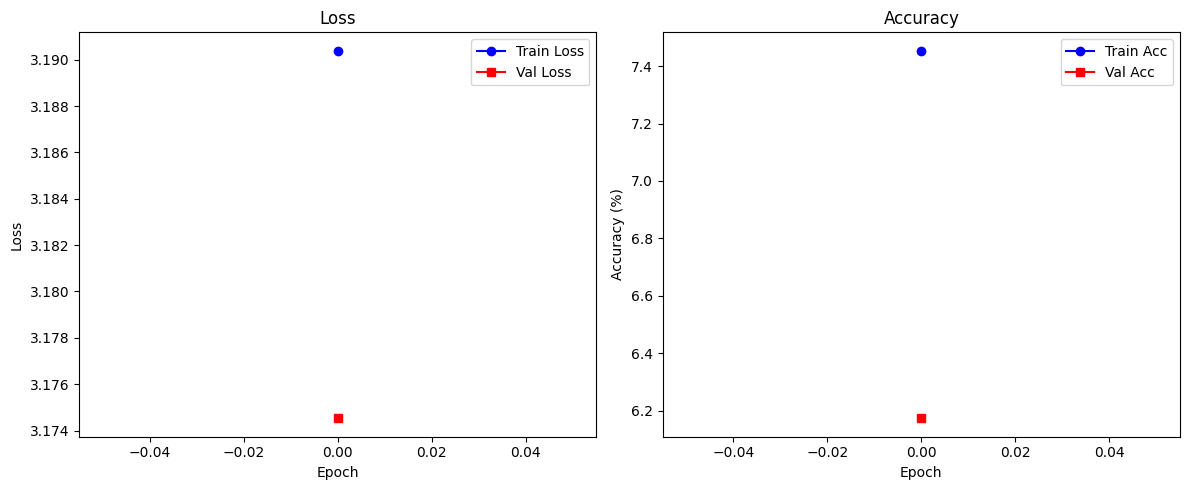

Epoch 2/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 29.67batch/s]


Train Loss: 3.0047, Train Acc: 12.18%
Val Loss: 2.9273, Val Acc: 14.81%
✓ Saved best model (val_acc: 14.81%)


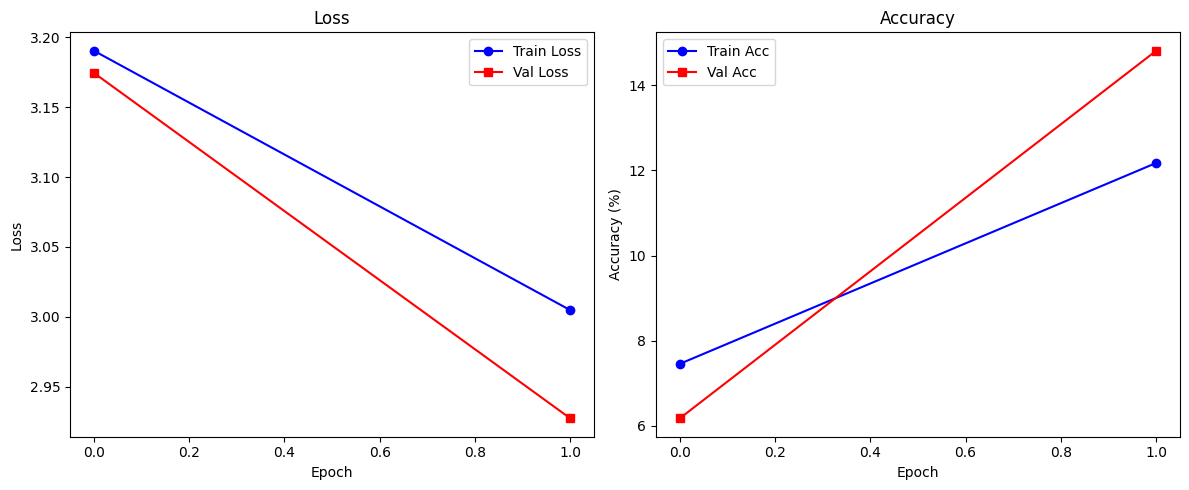

Epoch 3/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 30.87batch/s]


Train Loss: 2.9427, Train Acc: 13.82%
Val Loss: 2.7951, Val Acc: 13.58%


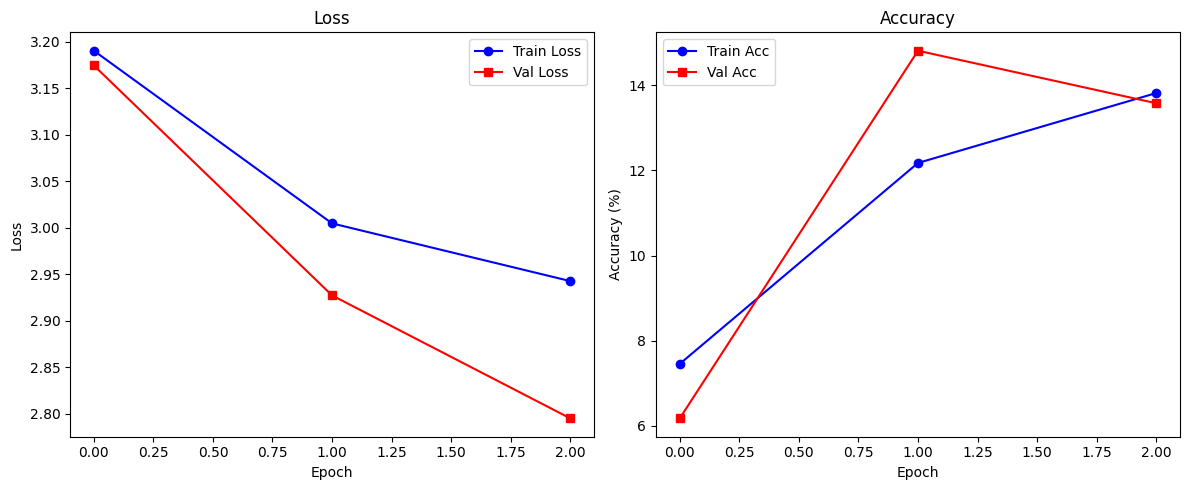

Epoch 4/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 31.16batch/s]


Train Loss: 2.8256, Train Acc: 17.34%
Val Loss: 2.7383, Val Acc: 23.46%
✓ Saved best model (val_acc: 23.46%)


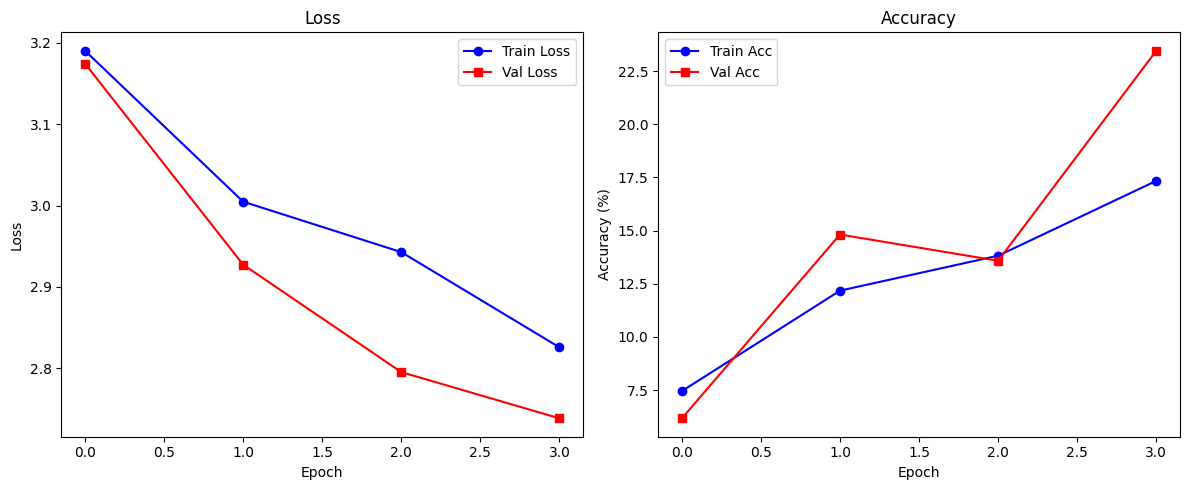

Epoch 5/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 29.33batch/s]

Train Loss: 2.7635, Train Acc: 18.94%
Val Loss: 2.5922, Val Acc: 20.99%


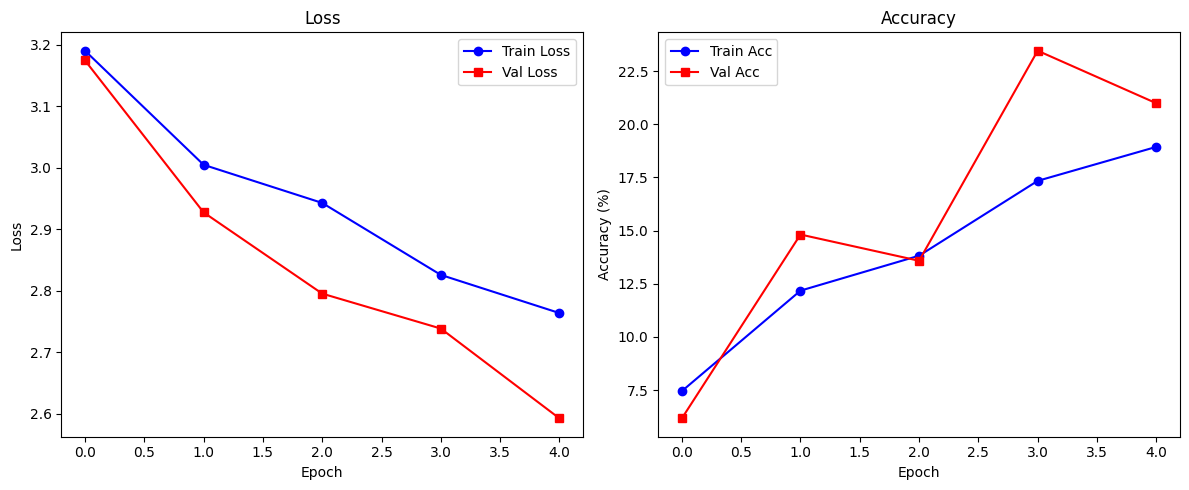

Epoch 6/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 33.07batch/s]


Train Loss: 2.6731, Train Acc: 20.53%
Val Loss: 2.5121, Val Acc: 24.69%
✓ Saved best model (val_acc: 24.69%)


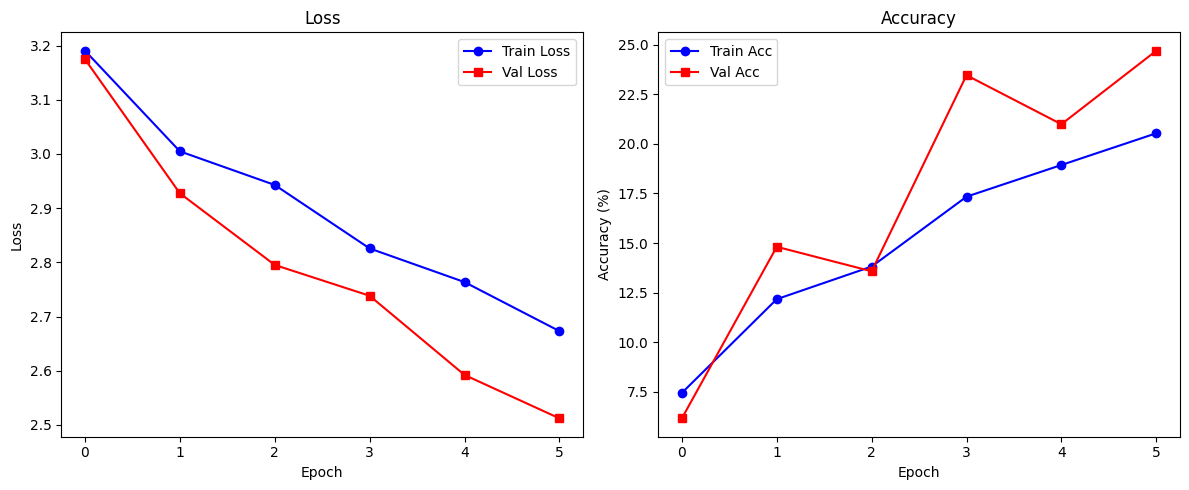

Epoch 7/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 30.77batch/s]


Train Loss: 2.6229, Train Acc: 20.76%
Val Loss: 2.6100, Val Acc: 20.99%


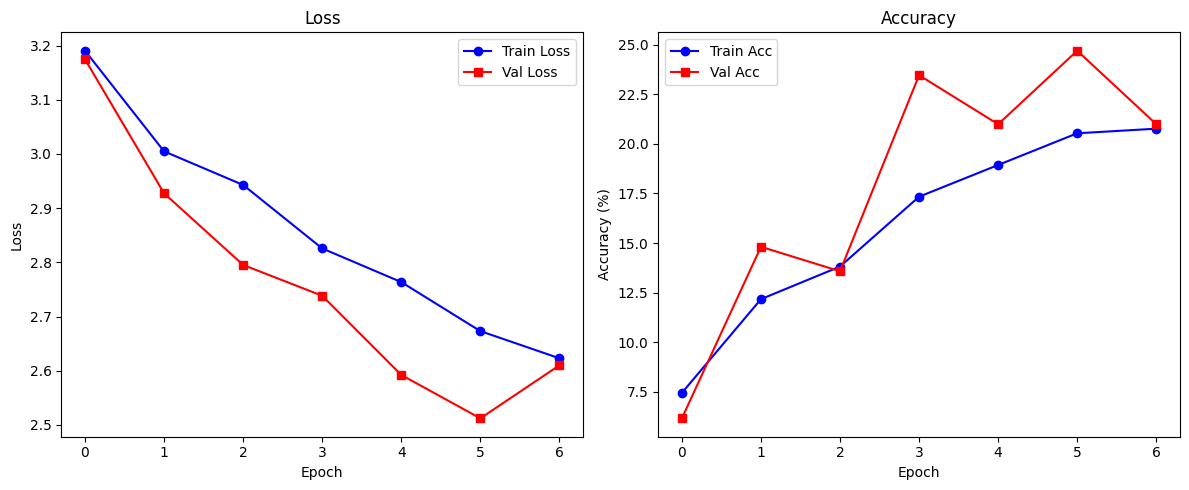

Epoch 8/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 30.41batch/s]


Train Loss: 2.5625, Train Acc: 22.66%
Val Loss: 2.5715, Val Acc: 19.75%


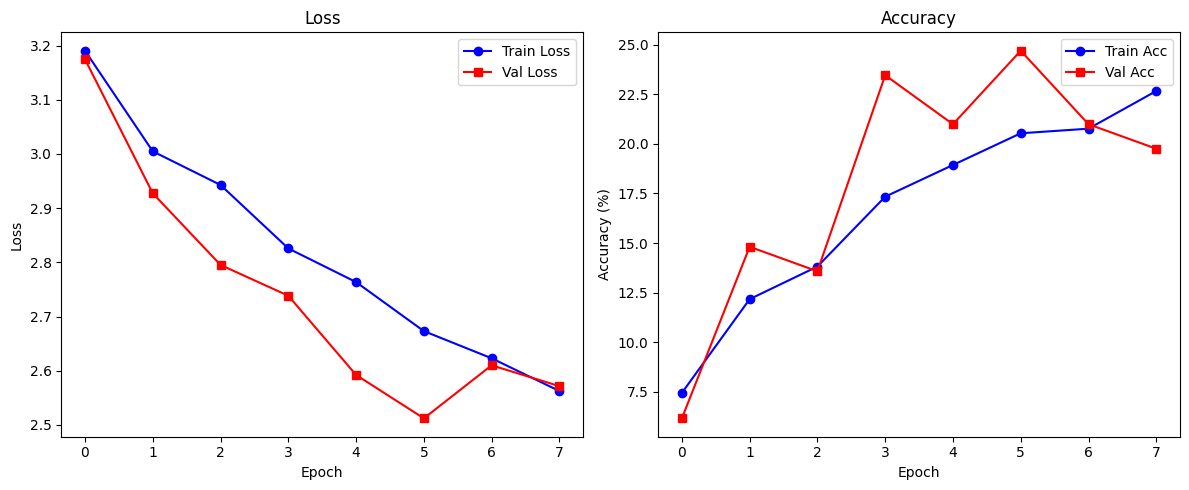

Epoch 9/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 29.50batch/s]

Train Loss: 2.5258, Train Acc: 23.59%
Val Loss: 2.5016, Val Acc: 22.22%


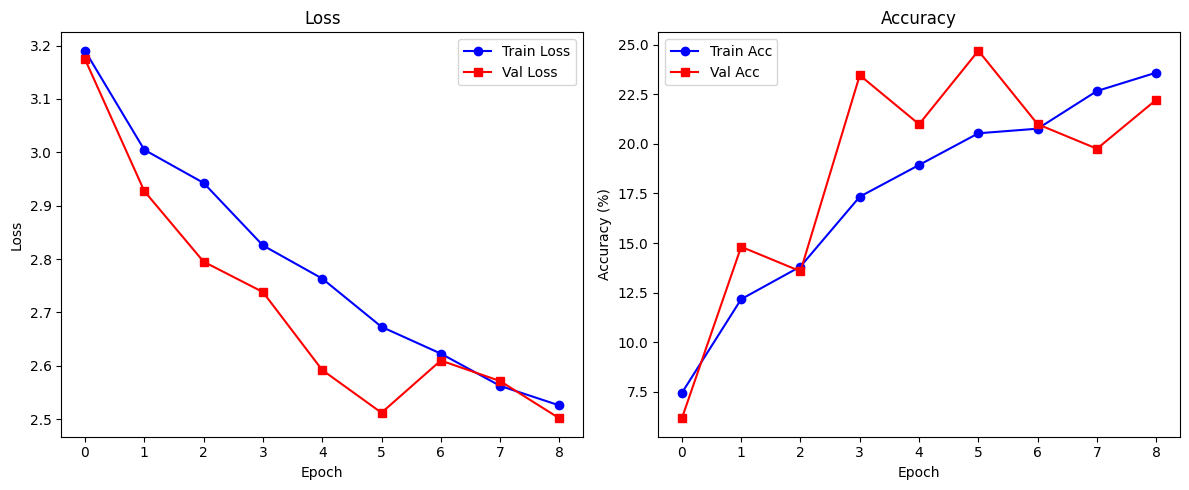

Epoch 10/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 30.40batch/s]


Train Loss: 2.4820, Train Acc: 24.58%
Val Loss: 2.4863, Val Acc: 17.28%


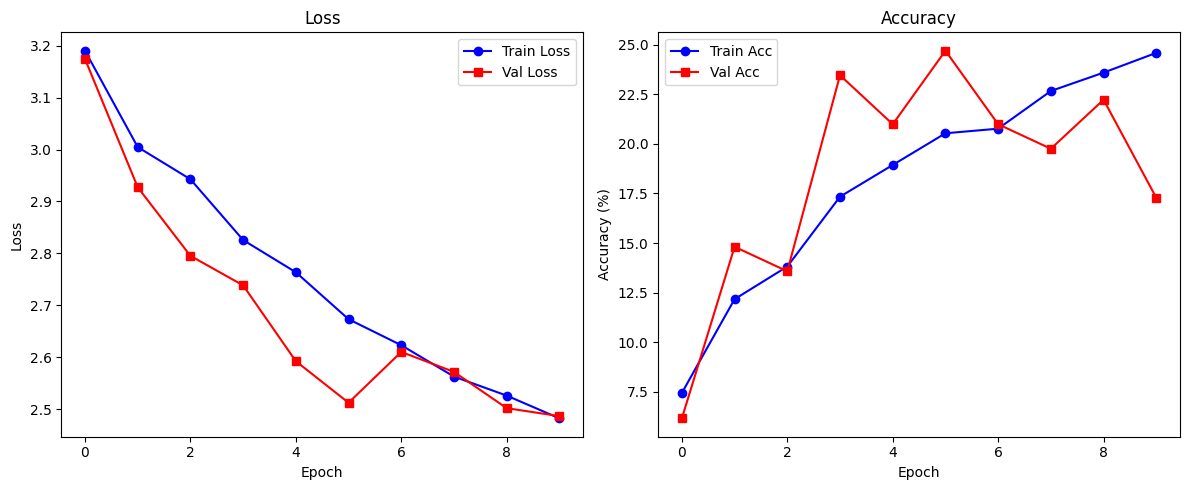

Epoch 11/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 30.67batch/s]


Train Loss: 2.4347, Train Acc: 25.65%
Val Loss: 2.4252, Val Acc: 27.16%
✓ Saved best model (val_acc: 27.16%)


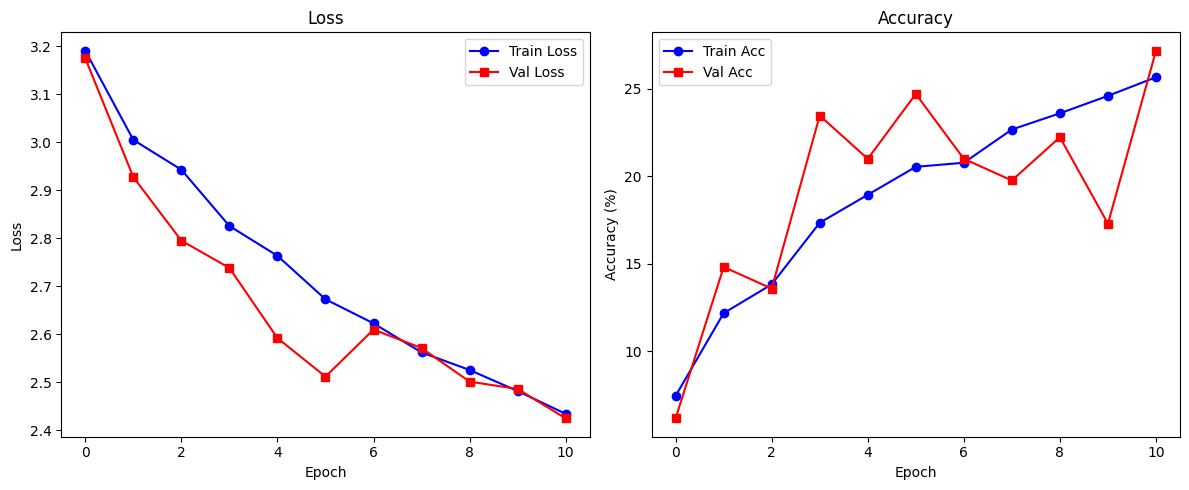

Epoch 12/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 29.99batch/s]

Train Loss: 2.4099, Train Acc: 26.23%
Val Loss: 2.4385, Val Acc: 18.52%


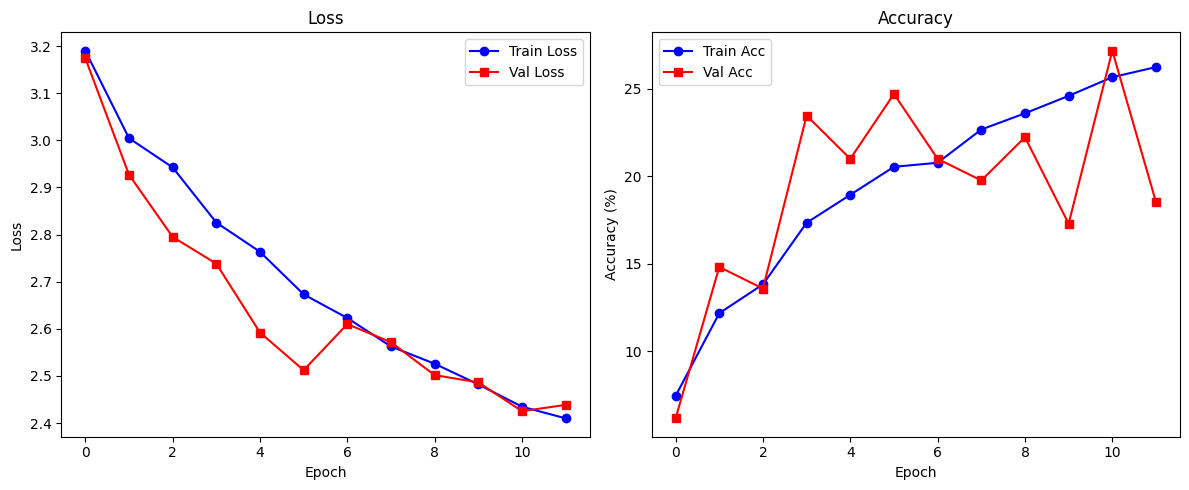

Epoch 13/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 30.00batch/s]

Train Loss: 2.3582, Train Acc: 26.92%
Val Loss: 2.3492, Val Acc: 20.99%


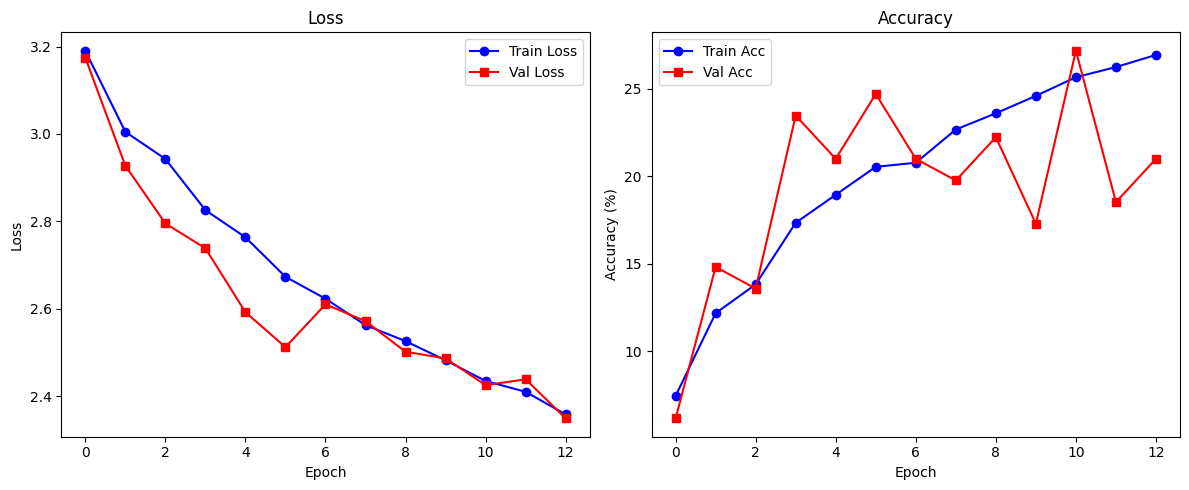

Epoch 14/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 30.45batch/s]


Train Loss: 2.3213, Train Acc: 28.29%
Val Loss: 2.2920, Val Acc: 27.16%


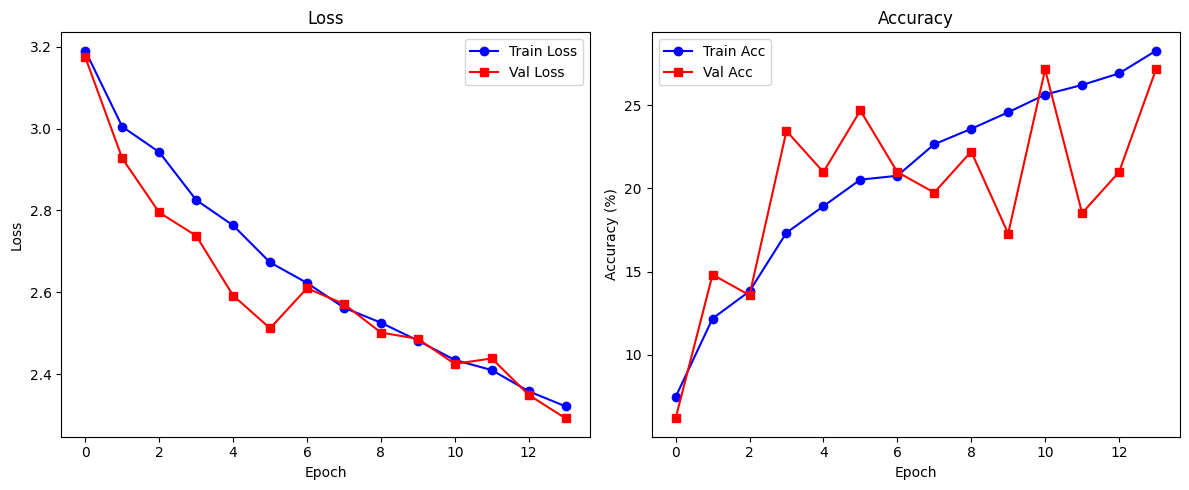

Epoch 15/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 30.15batch/s]


Train Loss: 2.3051, Train Acc: 29.10%
Val Loss: 2.2821, Val Acc: 25.93%


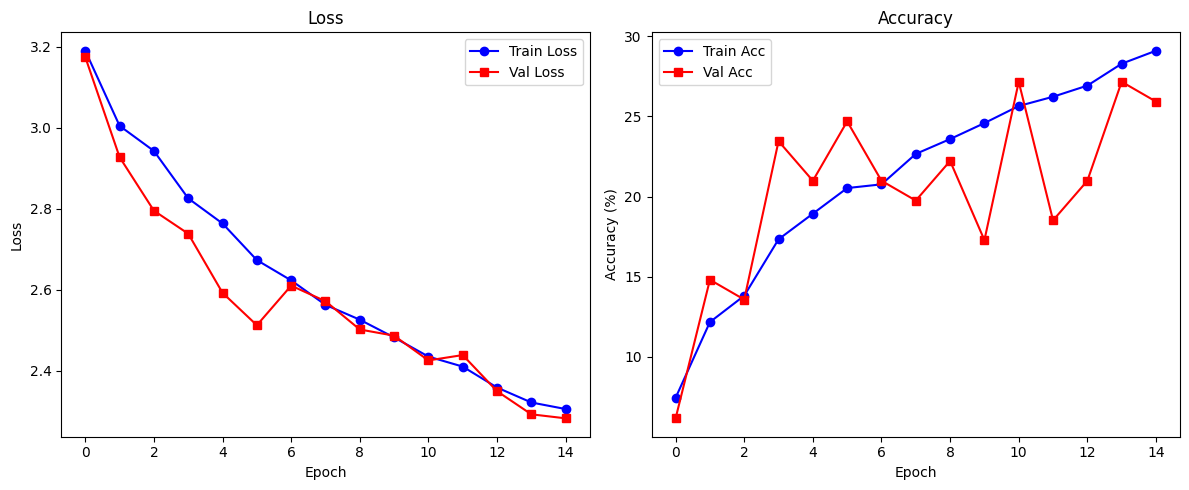

Epoch 16/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 29.45batch/s]


Train Loss: 2.2503, Train Acc: 30.09%
Val Loss: 2.1527, Val Acc: 29.63%
✓ Saved best model (val_acc: 29.63%)


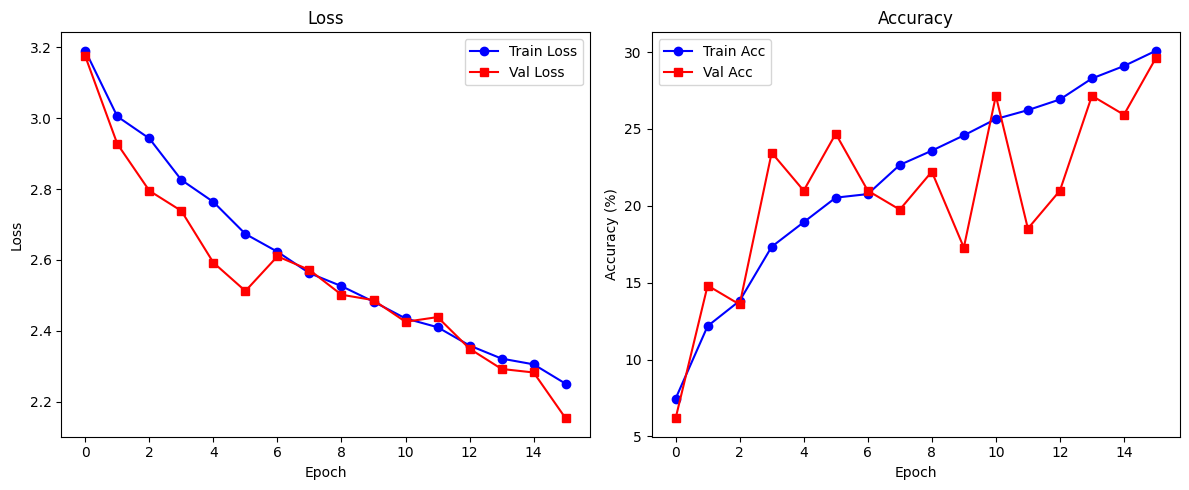

Epoch 17/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 28.84batch/s]

Train Loss: 2.2276, Train Acc: 31.02%
Val Loss: 2.1647, Val Acc: 27.16%


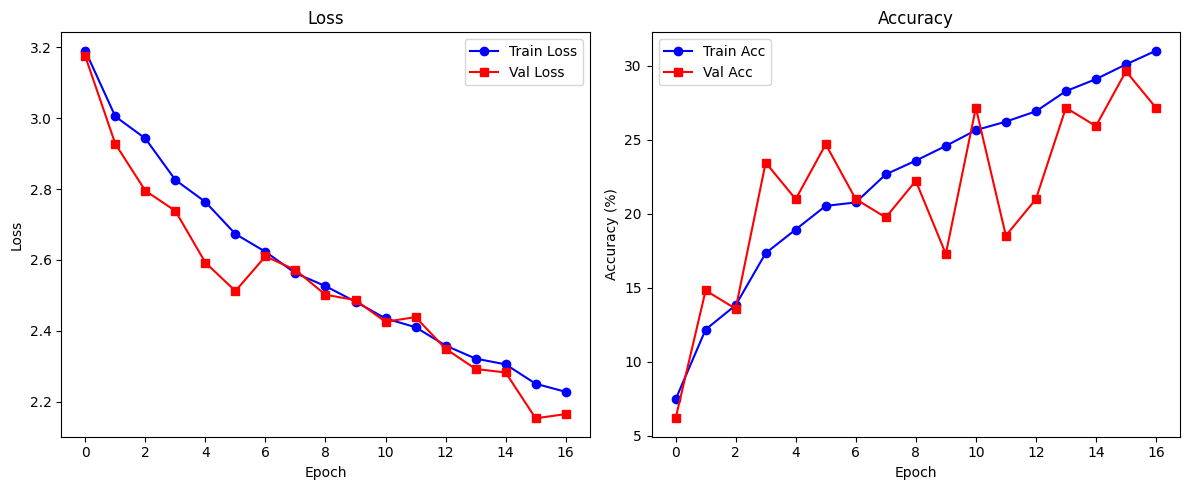

Epoch 18/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 30.57batch/s]


Train Loss: 2.2105, Train Acc: 30.95%
Val Loss: 2.1900, Val Acc: 25.93%


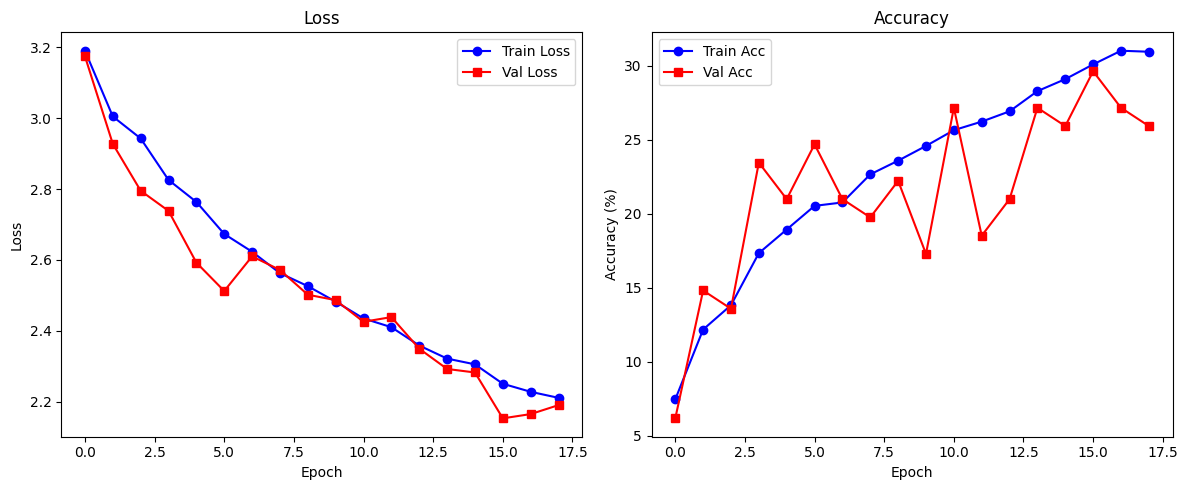

Epoch 19/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 30.24batch/s]


Train Loss: 2.1667, Train Acc: 32.64%
Val Loss: 2.0839, Val Acc: 28.40%


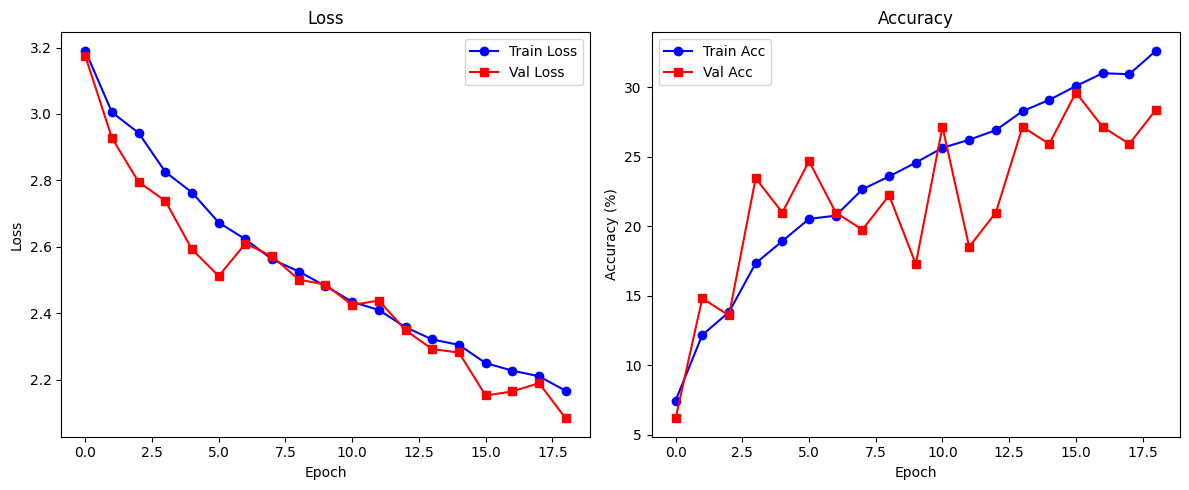

Epoch 20/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 31.61batch/s]


Train Loss: 2.1466, Train Acc: 33.70%
Val Loss: 2.1088, Val Acc: 29.63%


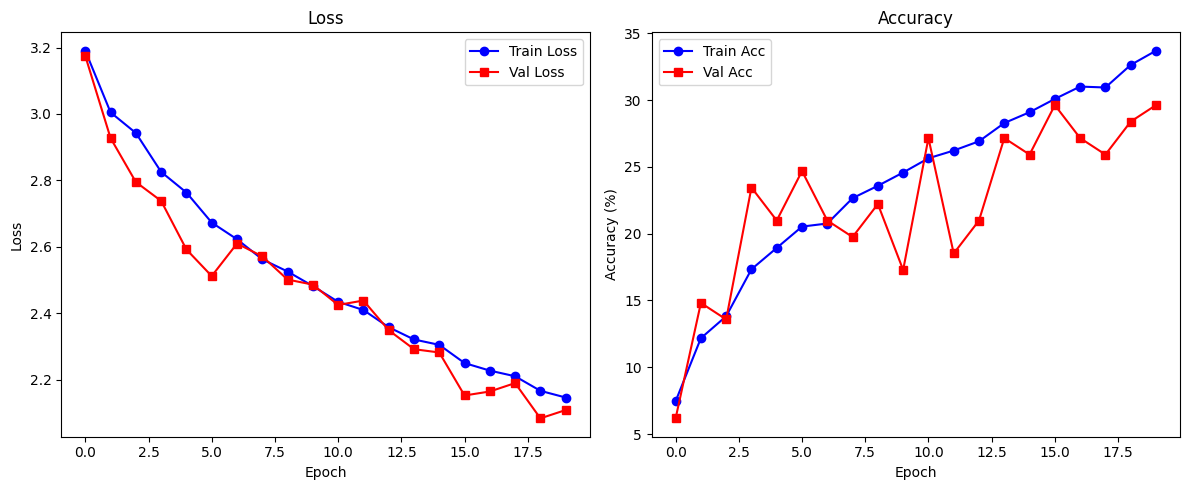

Epoch 21/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 30.40batch/s]


Train Loss: 2.1064, Train Acc: 34.12%
Val Loss: 1.9944, Val Acc: 35.80%
✓ Saved best model (val_acc: 35.80%)


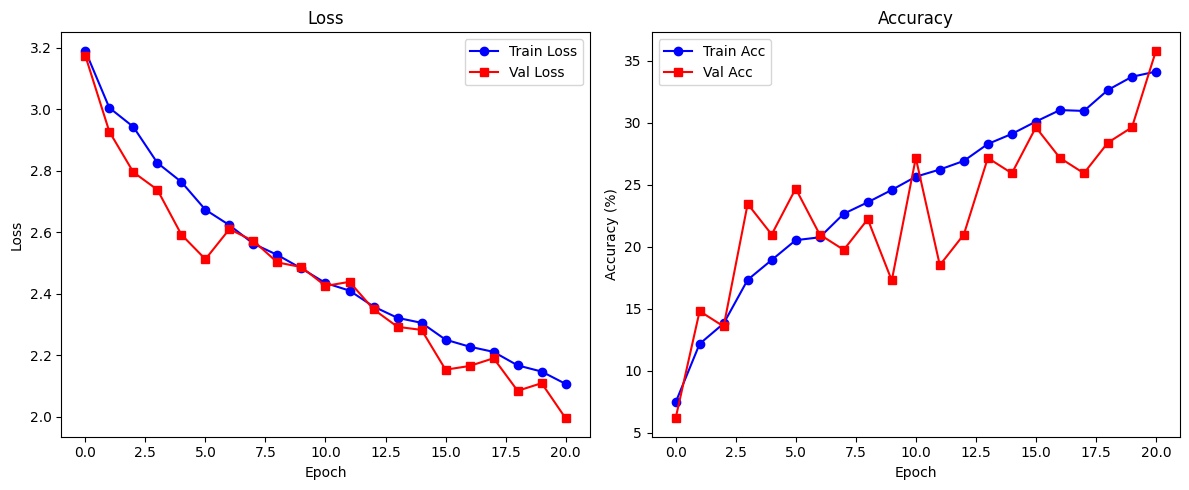

Epoch 22/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 30.06batch/s]


Train Loss: 2.0807, Train Acc: 35.58%
Val Loss: 2.0617, Val Acc: 34.57%


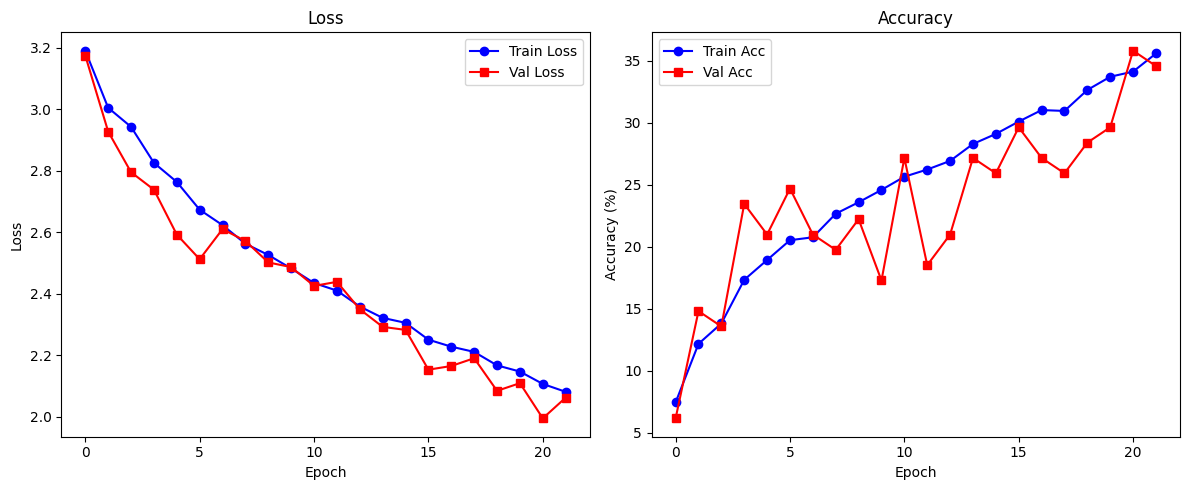

Epoch 23/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 31.03batch/s]


Train Loss: 2.0797, Train Acc: 34.17%
Val Loss: 2.0684, Val Acc: 38.27%
✓ Saved best model (val_acc: 38.27%)


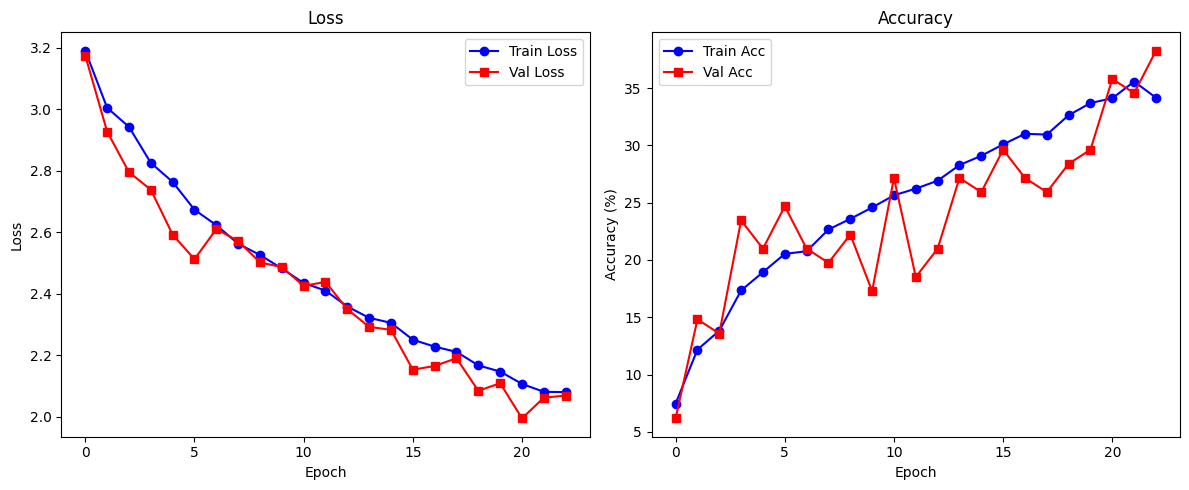

Epoch 24/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 31.56batch/s]


Train Loss: 2.0356, Train Acc: 36.09%
Val Loss: 1.9590, Val Acc: 43.21%
✓ Saved best model (val_acc: 43.21%)


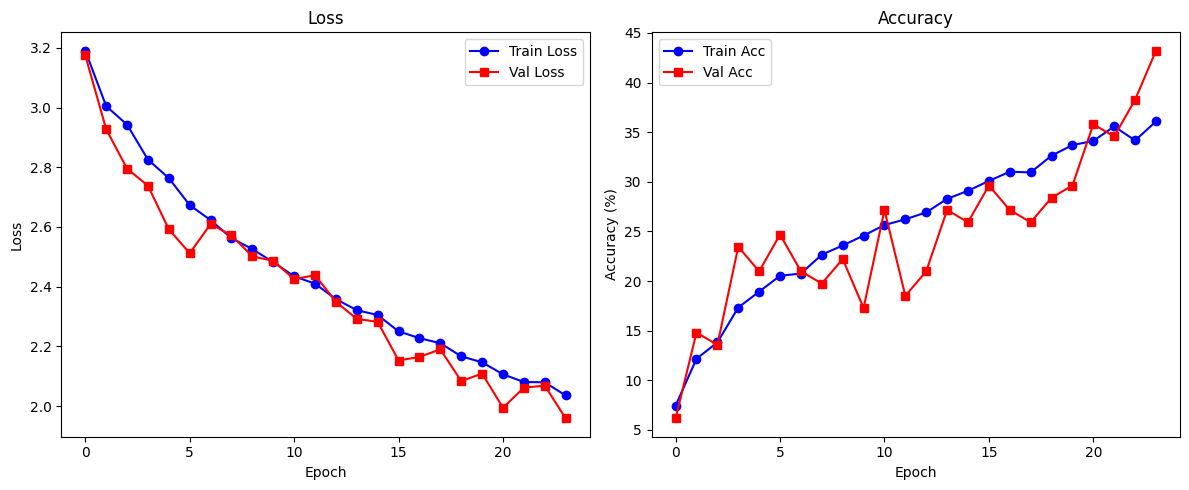

Epoch 25/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 31.64batch/s]


Train Loss: 2.0009, Train Acc: 36.83%
Val Loss: 1.9429, Val Acc: 37.04%


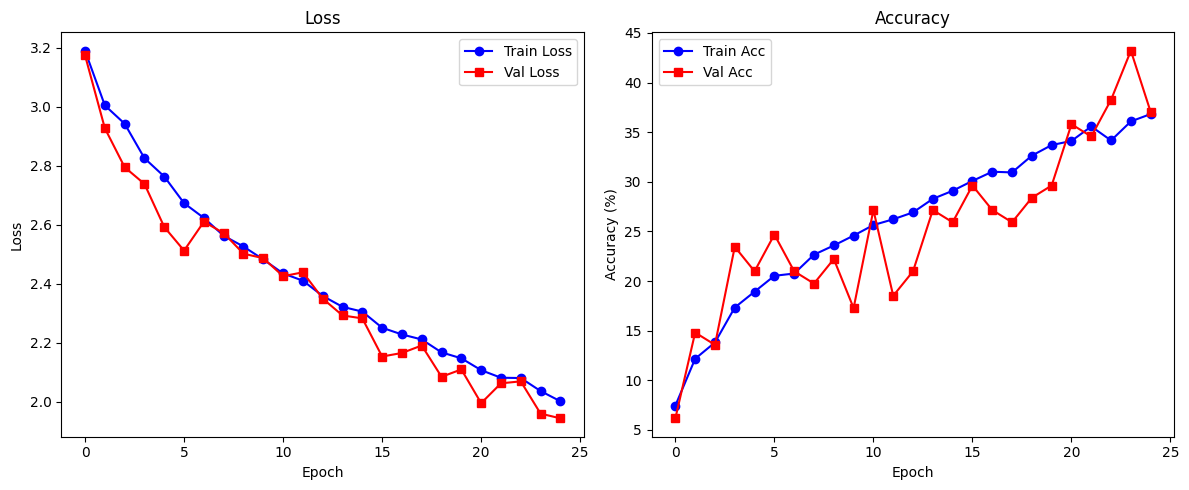

Epoch 26/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 32.24batch/s]


Train Loss: 1.9764, Train Acc: 38.26%
Val Loss: 2.0254, Val Acc: 33.33%


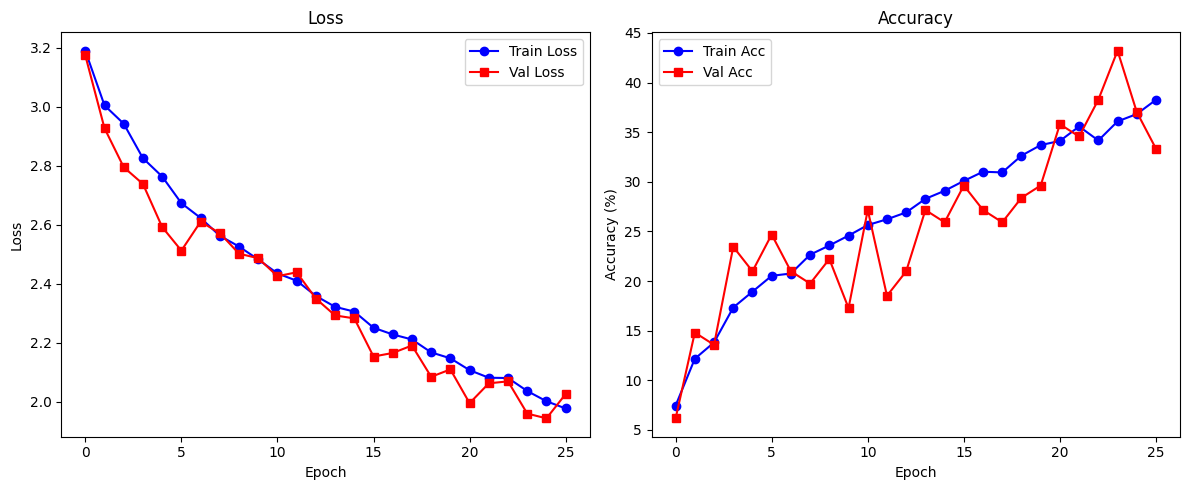

Epoch 27/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 30.78batch/s]


Train Loss: 1.9444, Train Acc: 38.68%
Val Loss: 1.8302, Val Acc: 37.04%


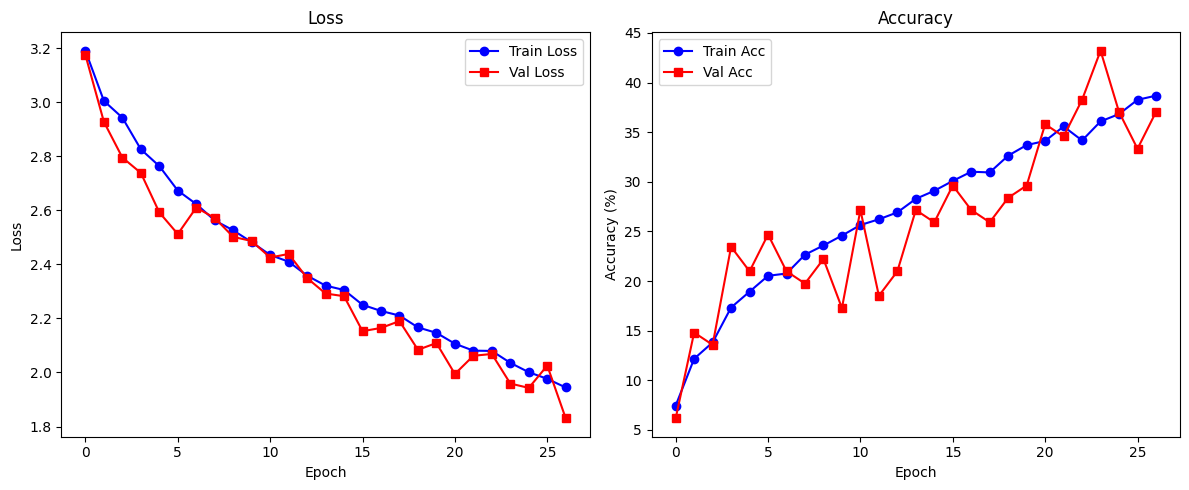

Epoch 28/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 30.84batch/s]


Train Loss: 1.9515, Train Acc: 37.85%
Val Loss: 1.9330, Val Acc: 35.80%


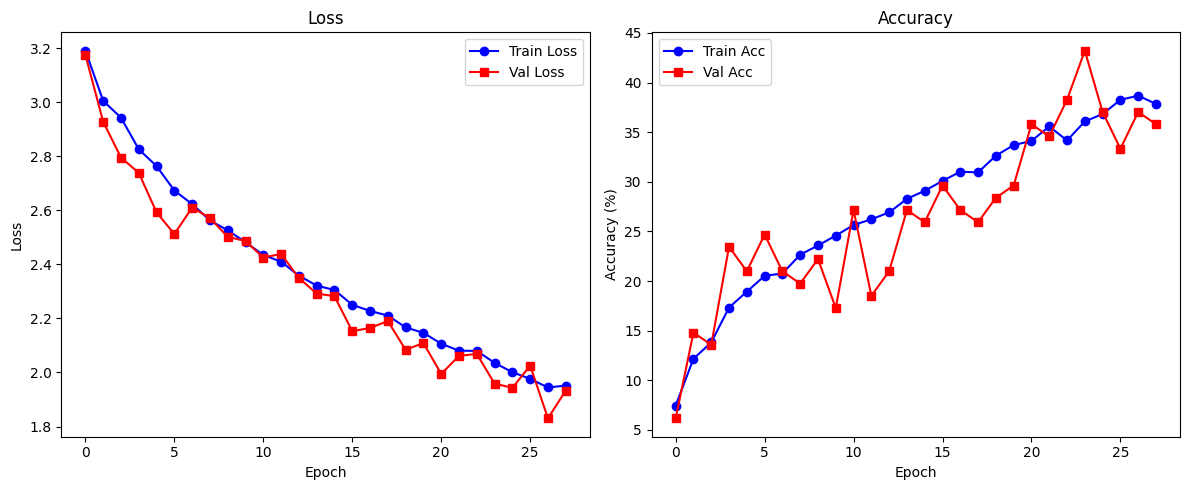

Epoch 29/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 30.60batch/s]


Train Loss: 1.8888, Train Acc: 40.12%
Val Loss: 1.8867, Val Acc: 35.80%


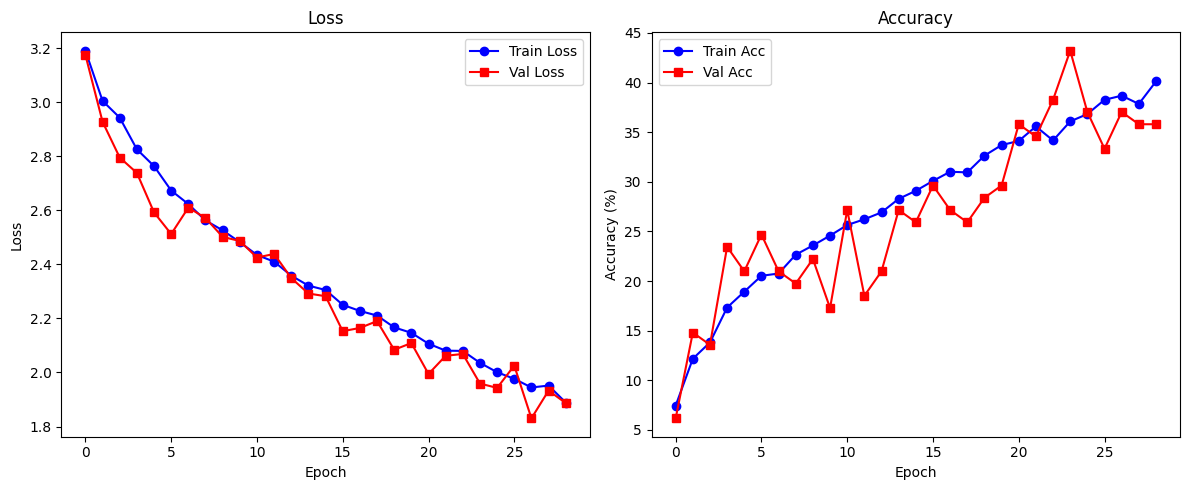

Epoch 30/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 31.43batch/s]


Train Loss: 1.9033, Train Acc: 39.31%
Val Loss: 1.8625, Val Acc: 39.51%


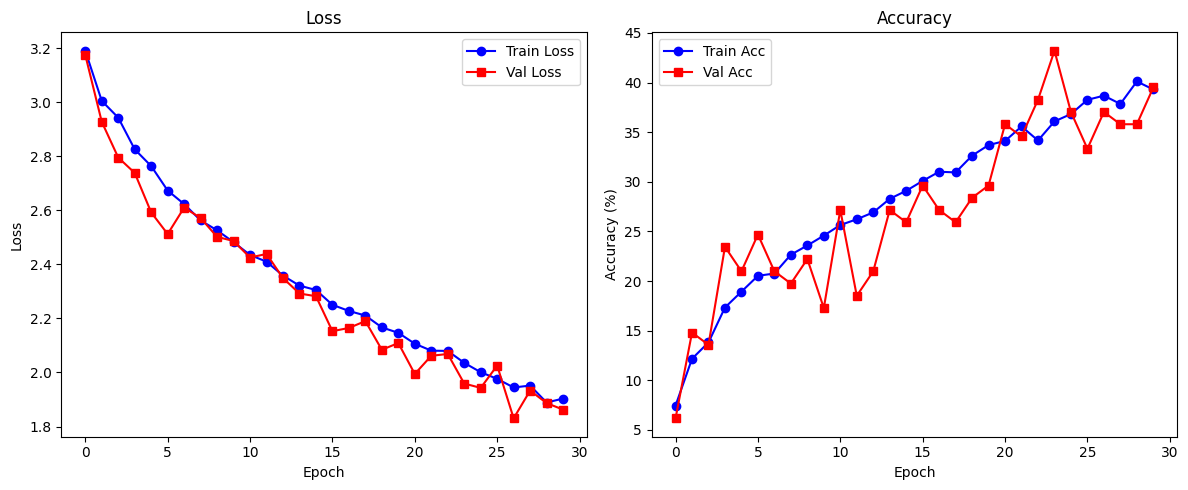

Epoch 31/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 30.65batch/s]


Train Loss: 1.8489, Train Acc: 41.99%
Val Loss: 1.8785, Val Acc: 43.21%


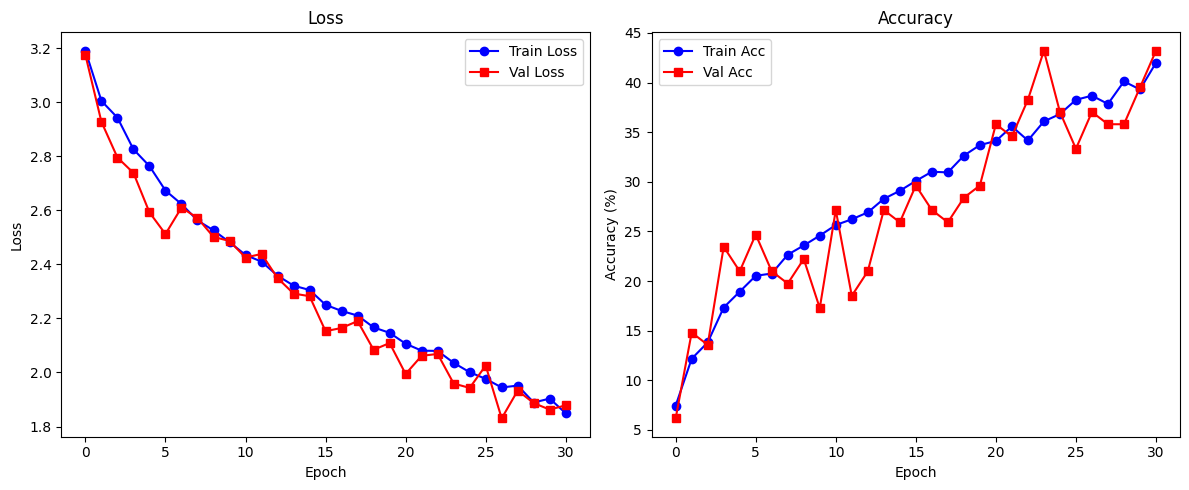

Epoch 32/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 29.70batch/s]

Train Loss: 1.7582, Train Acc: 44.24%
Val Loss: 1.7982, Val Acc: 43.21%


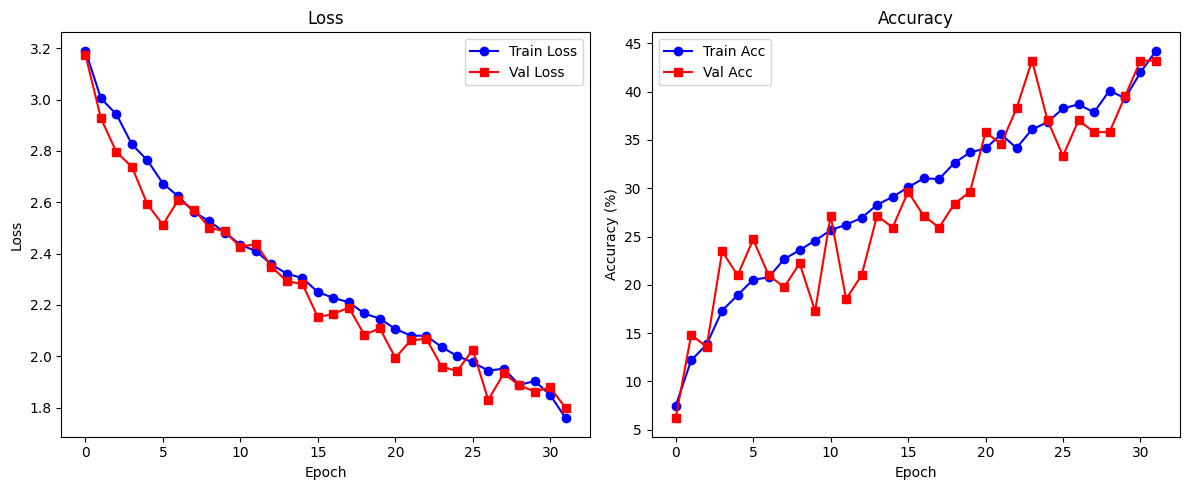

Epoch 33/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 30.88batch/s]


Train Loss: 1.7685, Train Acc: 44.79%
Val Loss: 1.8200, Val Acc: 45.68%
✓ Saved best model (val_acc: 45.68%)


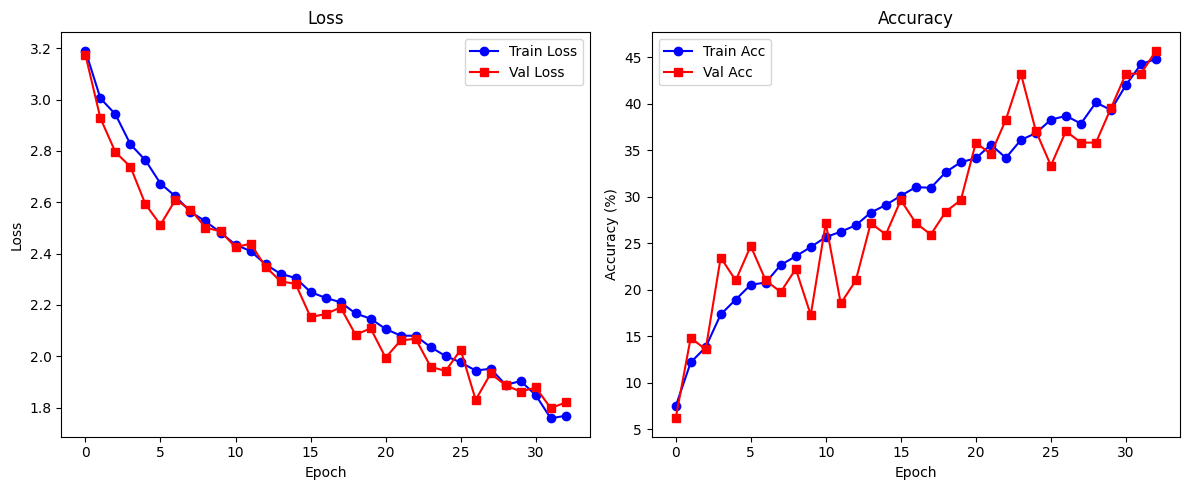

Epoch 34/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 30.87batch/s]


Train Loss: 1.7588, Train Acc: 44.81%
Val Loss: 1.8056, Val Acc: 41.98%


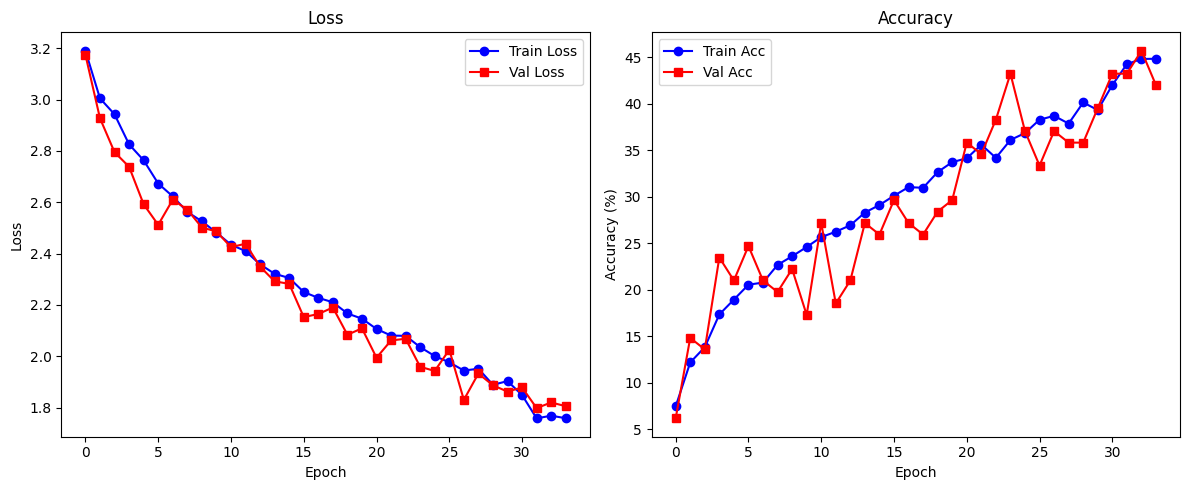

Epoch 35/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 29.31batch/s]

Train Loss: 1.7283, Train Acc: 45.05%
Val Loss: 1.7728, Val Acc: 43.21%


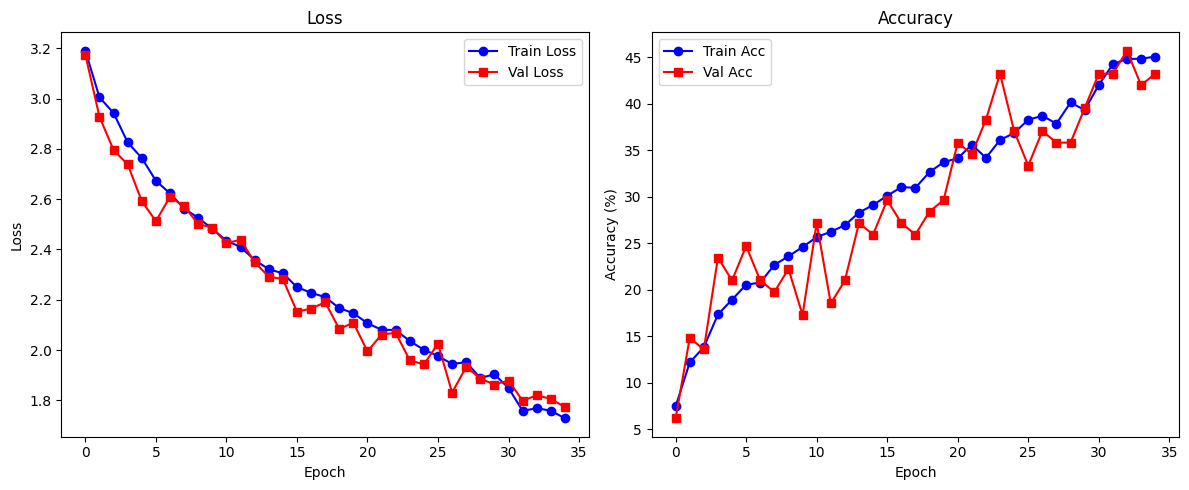

Epoch 36/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 29.32batch/s]

Train Loss: 1.7364, Train Acc: 44.12%
Val Loss: 1.7826, Val Acc: 43.21%


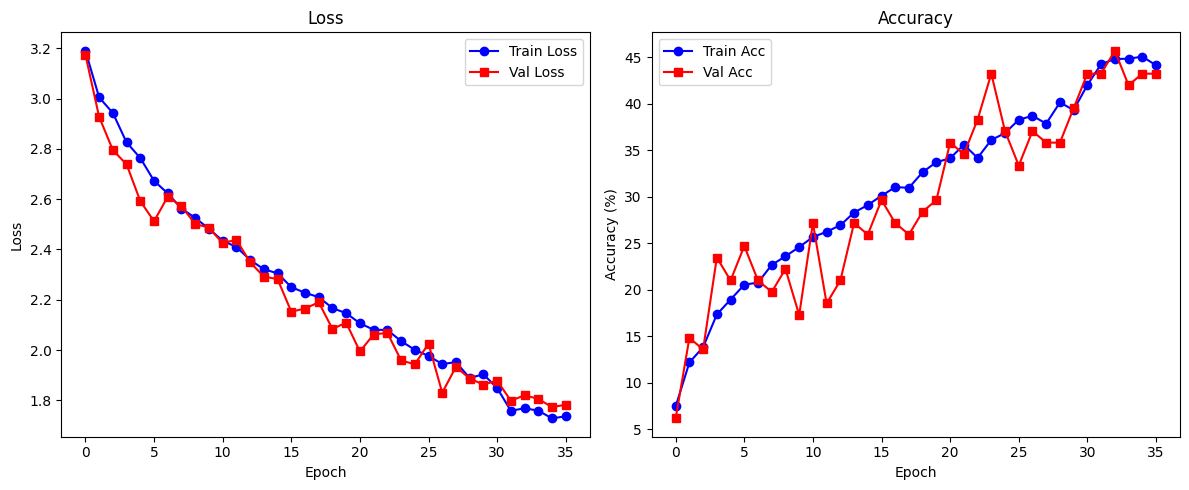

Epoch 37/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 30.33batch/s]


Train Loss: 1.7287, Train Acc: 45.60%
Val Loss: 1.7865, Val Acc: 44.44%


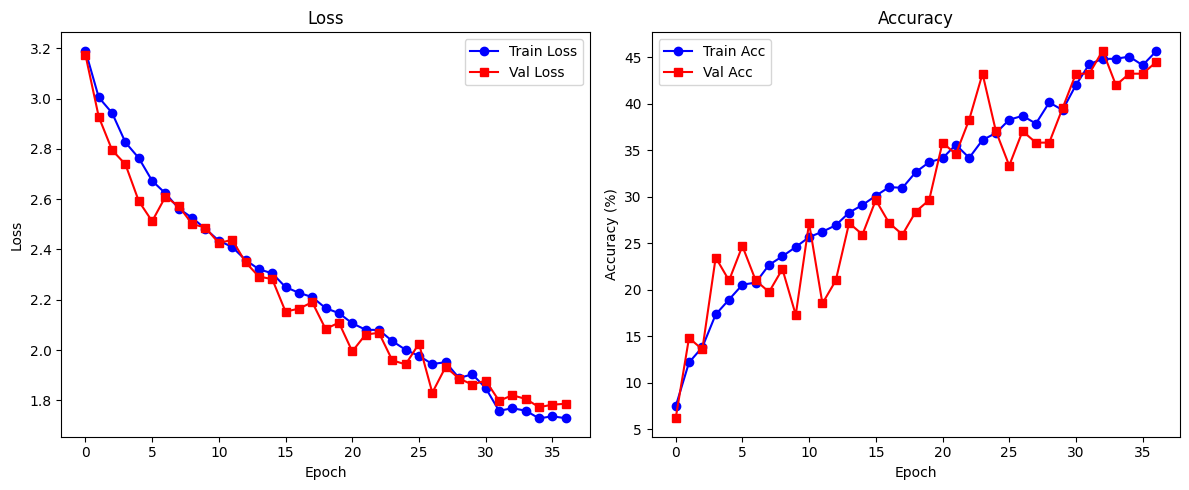

Epoch 38/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 30.29batch/s]


Train Loss: 1.7057, Train Acc: 45.69%
Val Loss: 1.7707, Val Acc: 41.98%


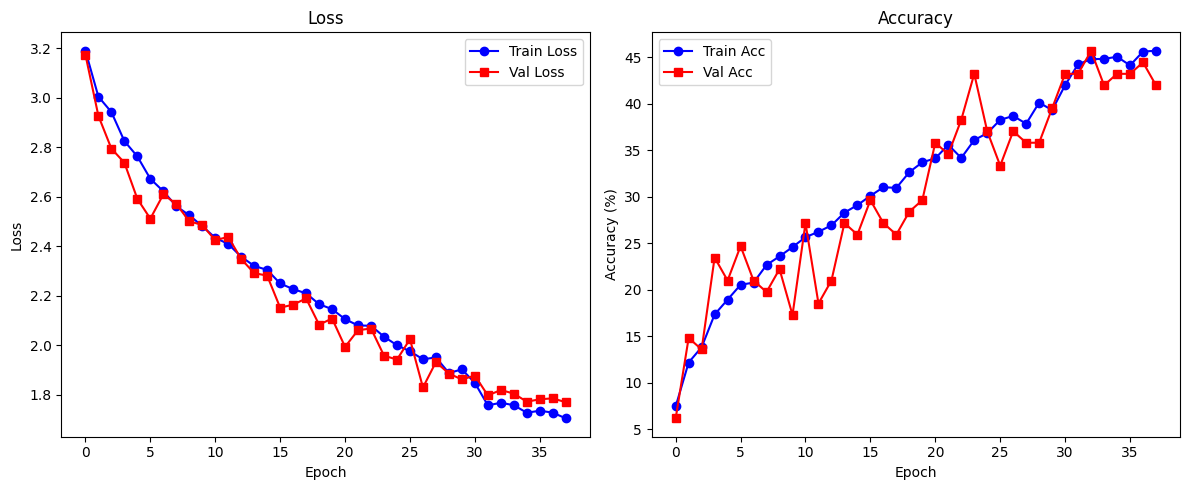

Epoch 39/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 30.77batch/s]


Train Loss: 1.7202, Train Acc: 45.67%
Val Loss: 1.7970, Val Acc: 43.21%


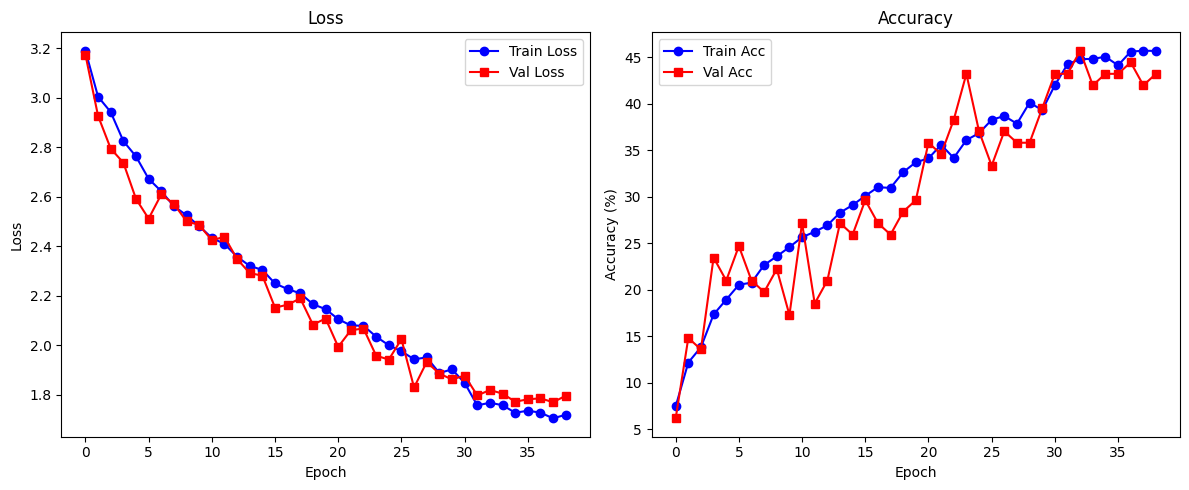

Epoch 40/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 31.21batch/s]


Train Loss: 1.6950, Train Acc: 45.95%
Val Loss: 1.7569, Val Acc: 41.98%


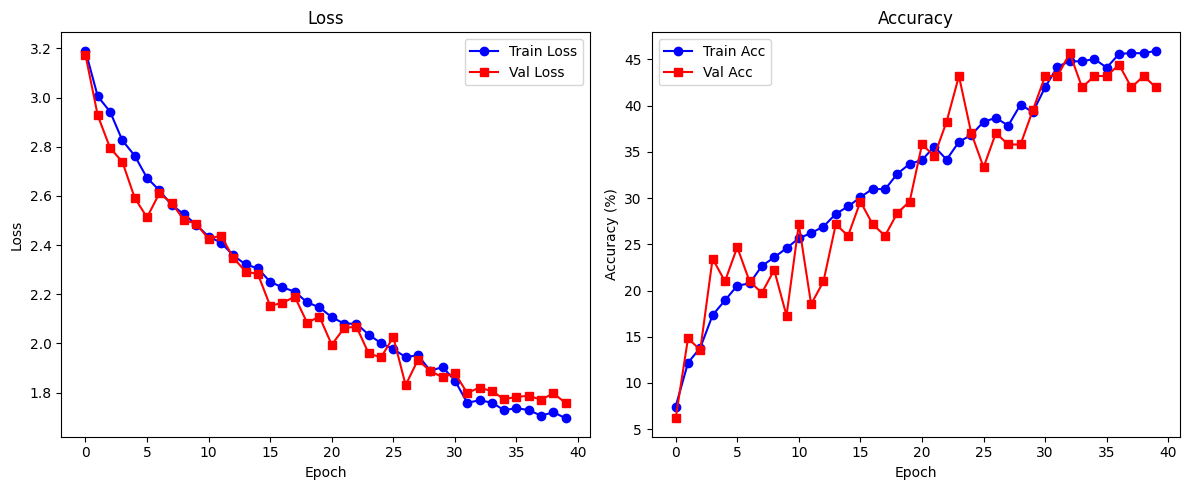

Epoch 41/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 29.46batch/s]

Train Loss: 1.6870, Train Acc: 45.74%
Val Loss: 1.7665, Val Acc: 40.74%


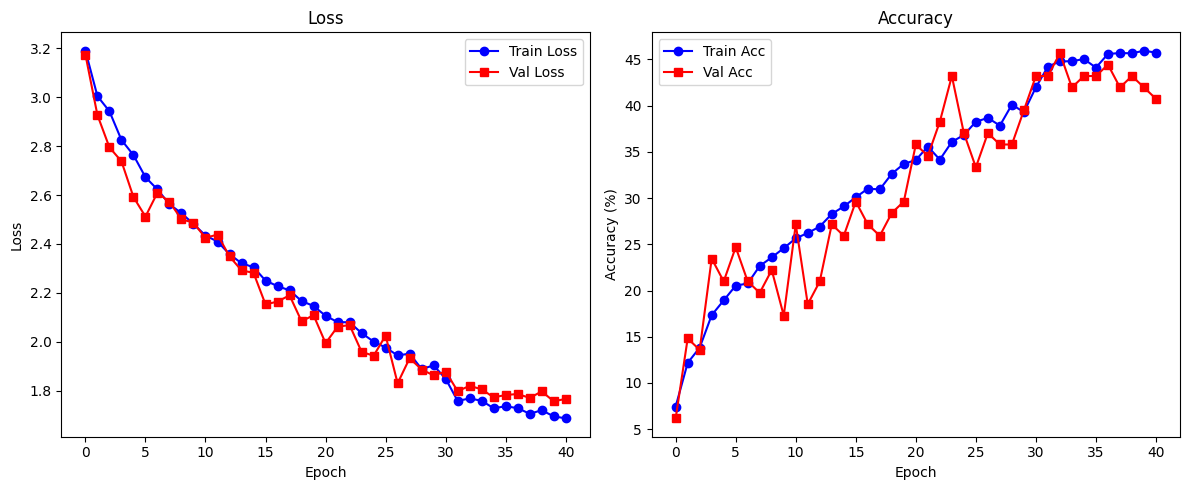

Epoch 42/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 29.06batch/s]


Train Loss: 1.7083, Train Acc: 46.27%
Val Loss: 1.7700, Val Acc: 48.15%
✓ Saved best model (val_acc: 48.15%)


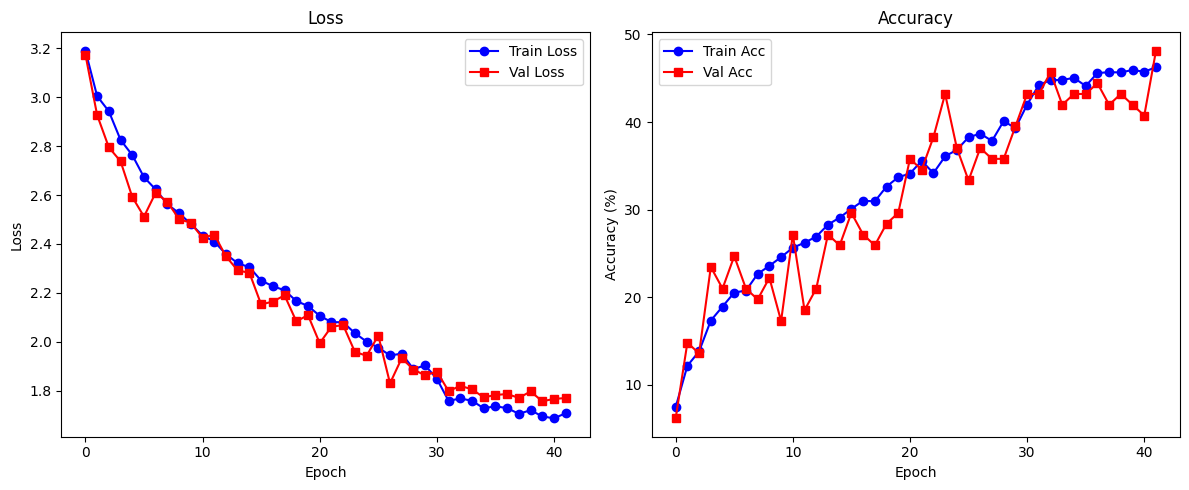

Epoch 43/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 26.43batch/s]

Train Loss: 1.6690, Train Acc: 46.62%
Val Loss: 1.7905, Val Acc: 44.44%


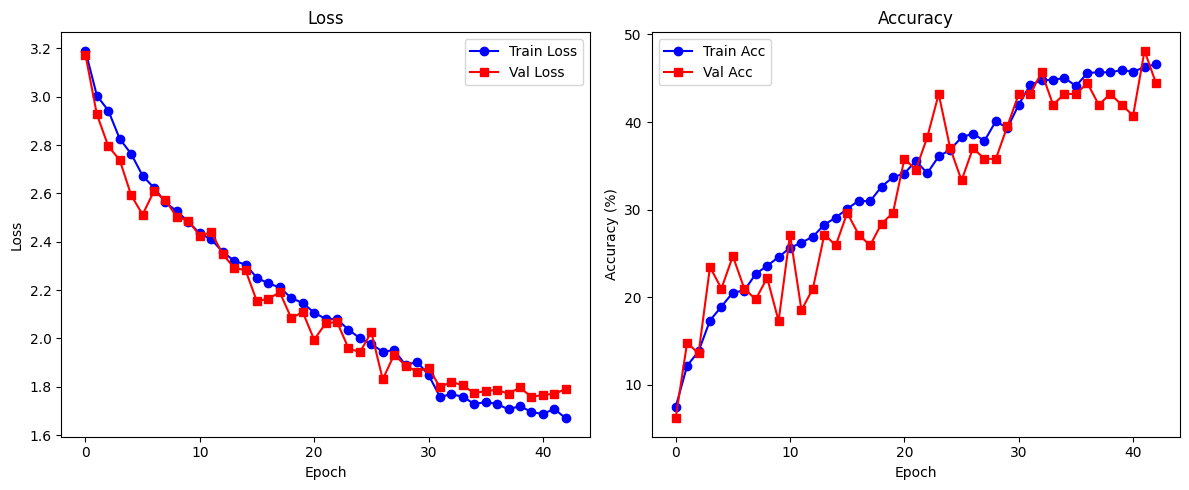

Epoch 44/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 29.22batch/s]

Train Loss: 1.6972, Train Acc: 45.51%
Val Loss: 1.7556, Val Acc: 45.68%


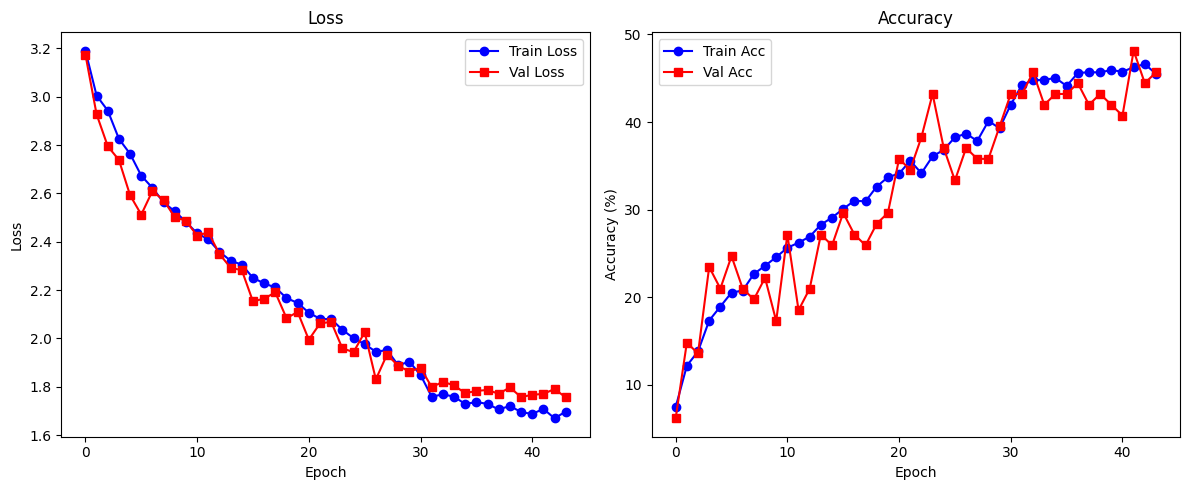

Epoch 45/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 31.34batch/s]


Train Loss: 1.6861, Train Acc: 45.46%
Val Loss: 1.7676, Val Acc: 44.44%


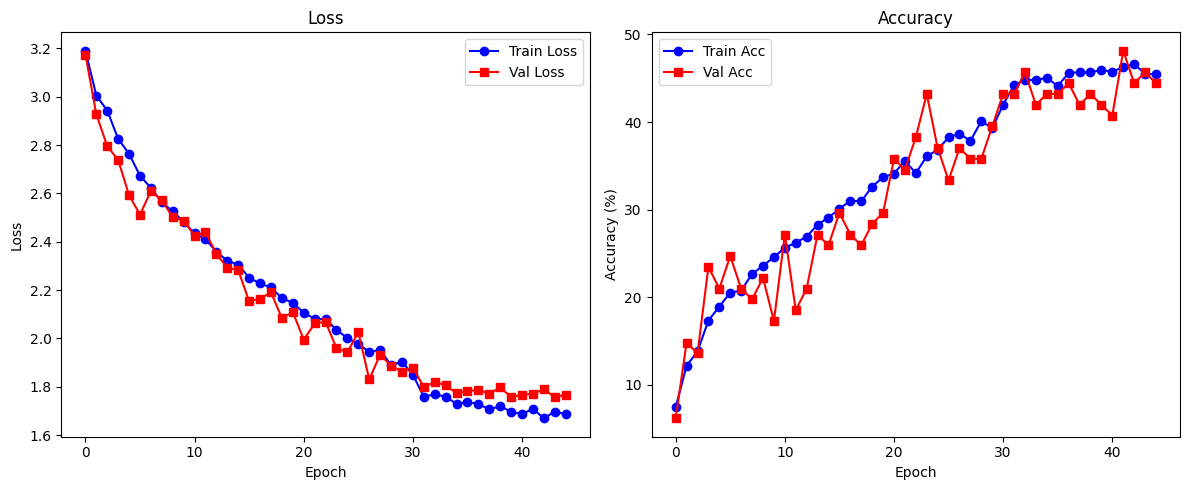

Epoch 46/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 31.33batch/s]


Train Loss: 1.6754, Train Acc: 46.69%
Val Loss: 1.7671, Val Acc: 45.68%


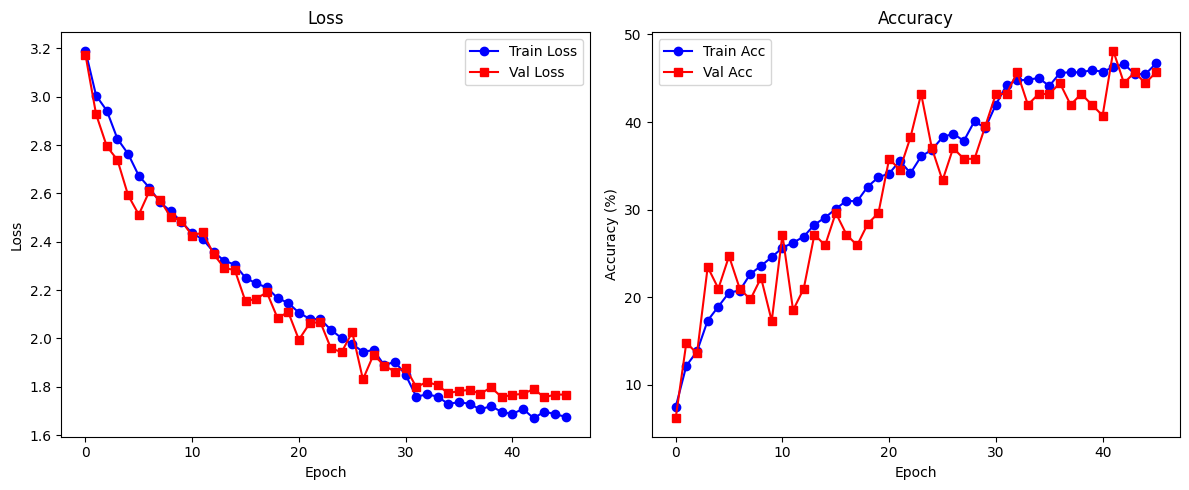

Epoch 47/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 31.57batch/s]


Train Loss: 1.6684, Train Acc: 46.78%
Val Loss: 1.7434, Val Acc: 49.38%
✓ Saved best model (val_acc: 49.38%)


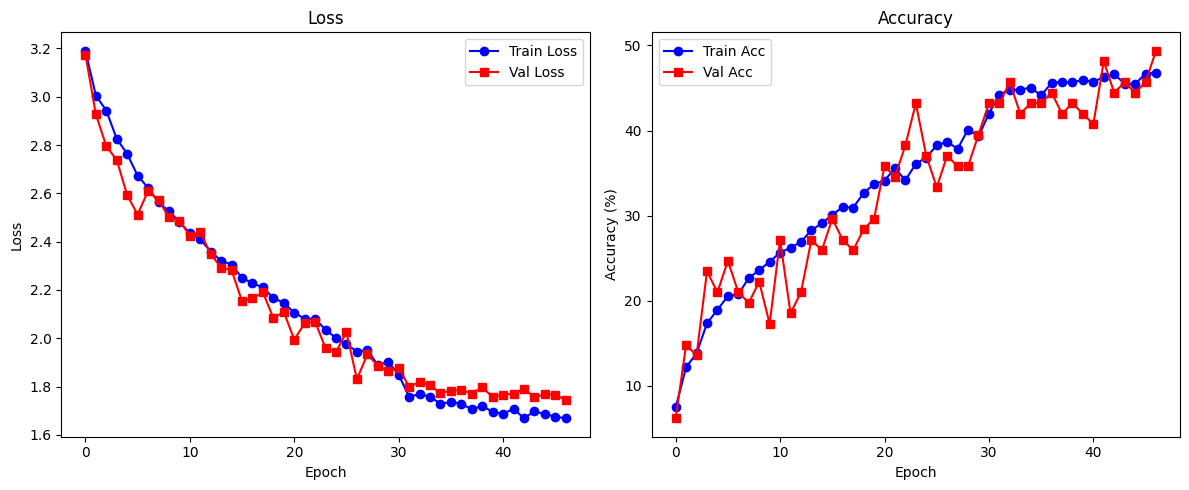

Epoch 48/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 25.38batch/s]

Train Loss: 1.6866, Train Acc: 45.83%
Val Loss: 1.7523, Val Acc: 43.21%


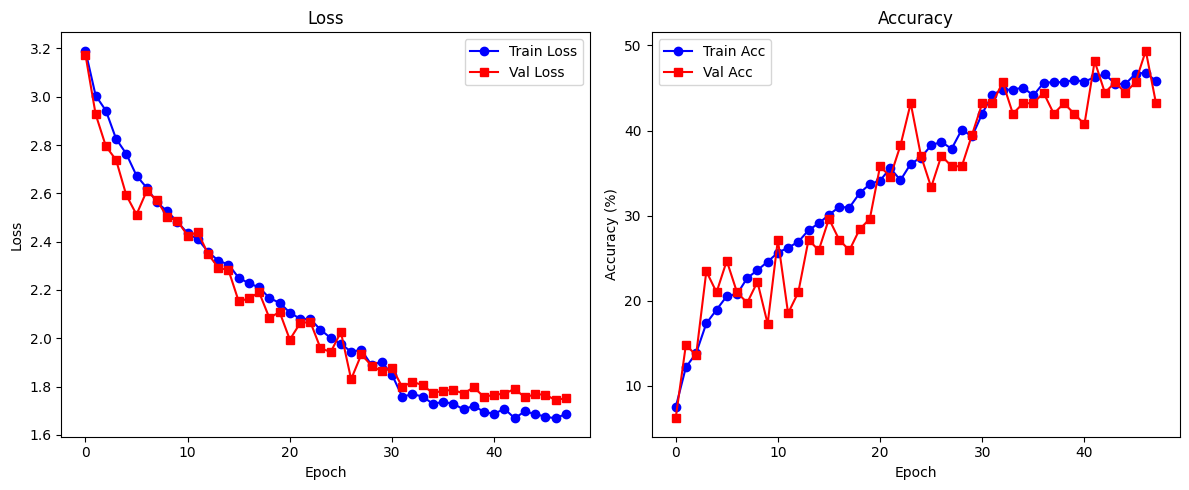

Epoch 49/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 29.18batch/s]

Train Loss: 1.6584, Train Acc: 47.43%
Val Loss: 1.7568, Val Acc: 43.21%


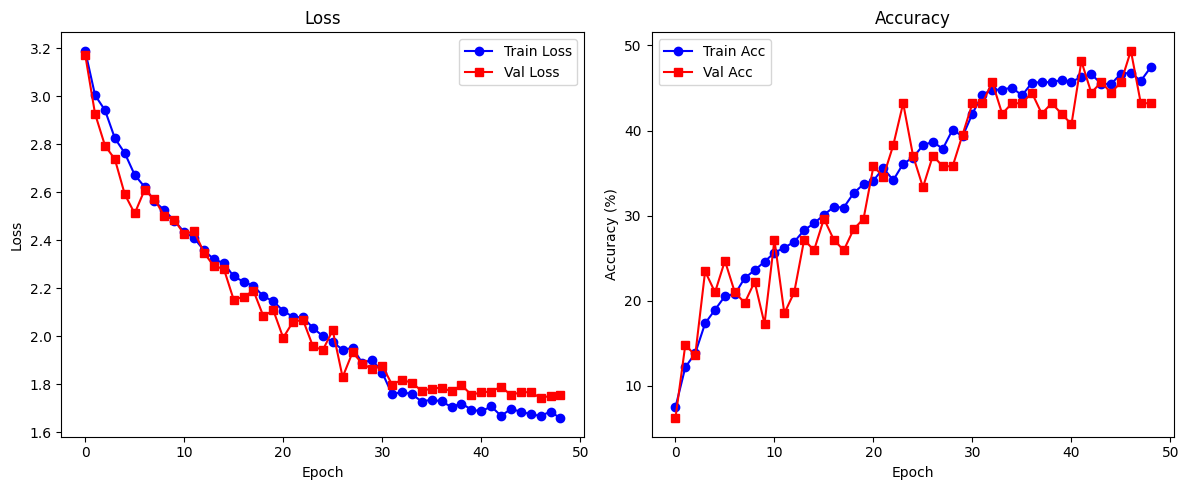

Epoch 50/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 32.36batch/s]


Train Loss: 1.6597, Train Acc: 47.82%
Val Loss: 1.7445, Val Acc: 44.44%


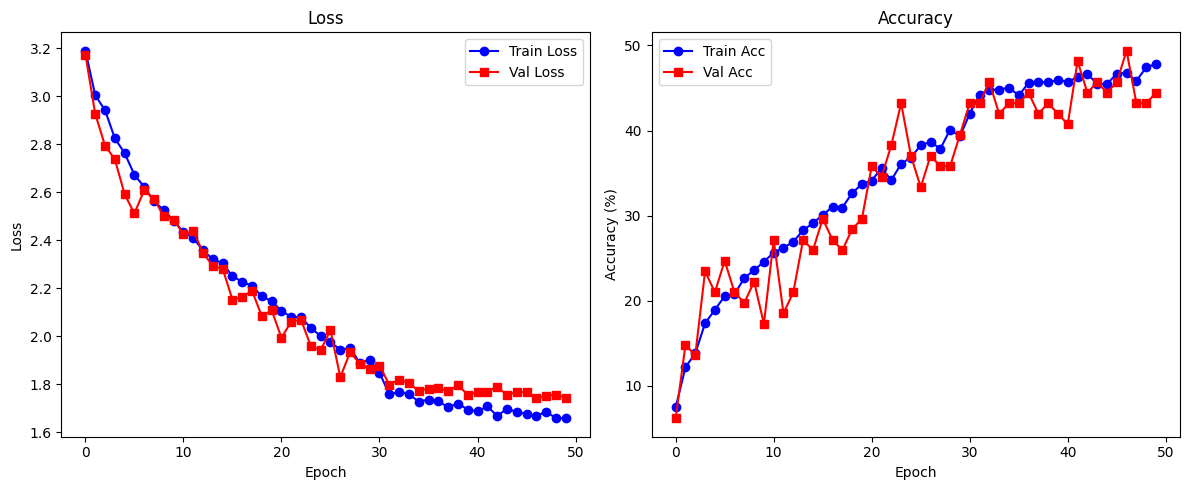

Epoch 51/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 30.57batch/s]


Train Loss: 1.6589, Train Acc: 47.15%
Val Loss: 1.7466, Val Acc: 48.15%


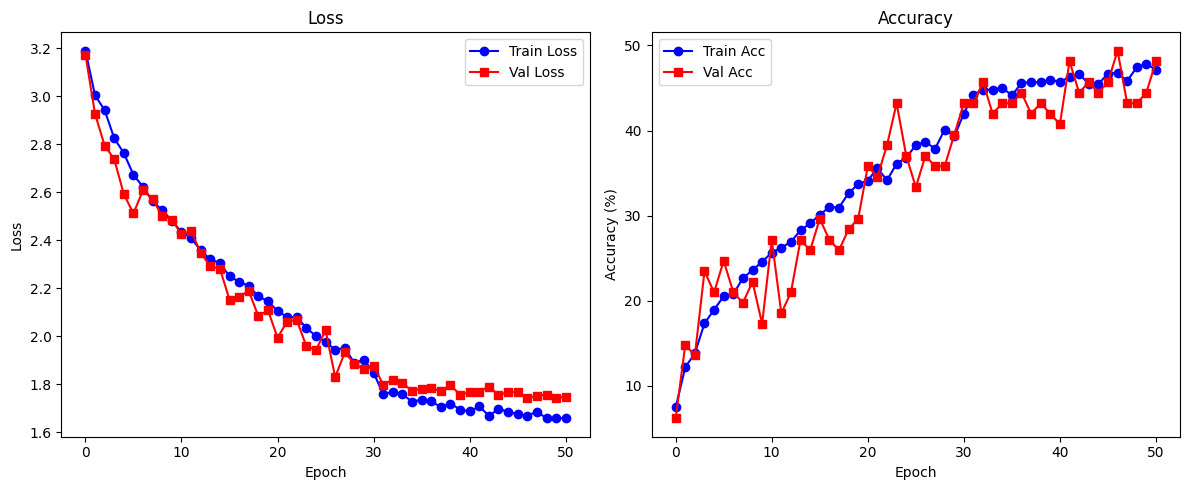

Epoch 52/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 27.83batch/s]

Train Loss: 1.6563, Train Acc: 46.90%
Val Loss: 1.7691, Val Acc: 46.91%


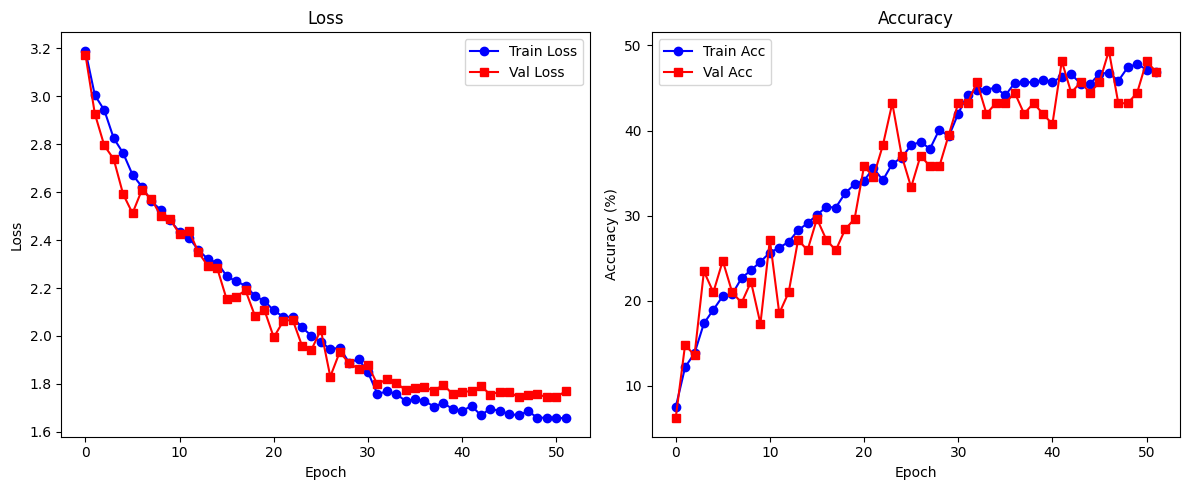

Epoch 53/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 29.10batch/s]

Train Loss: 1.6478, Train Acc: 47.99%
Val Loss: 1.7686, Val Acc: 46.91%


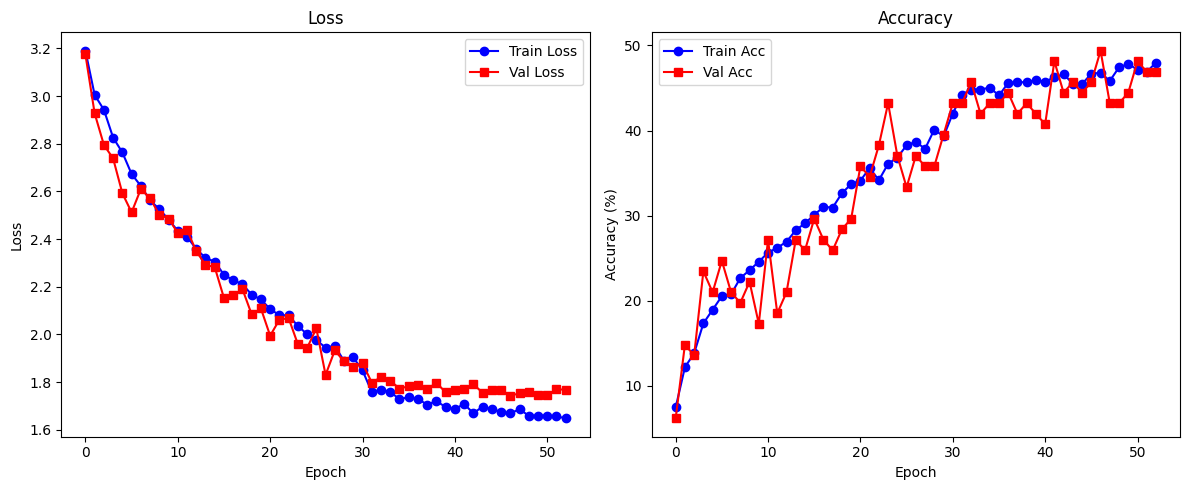

Epoch 54/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 28.05batch/s]


Train Loss: 1.6512, Train Acc: 47.45%
Val Loss: 1.7462, Val Acc: 45.68%


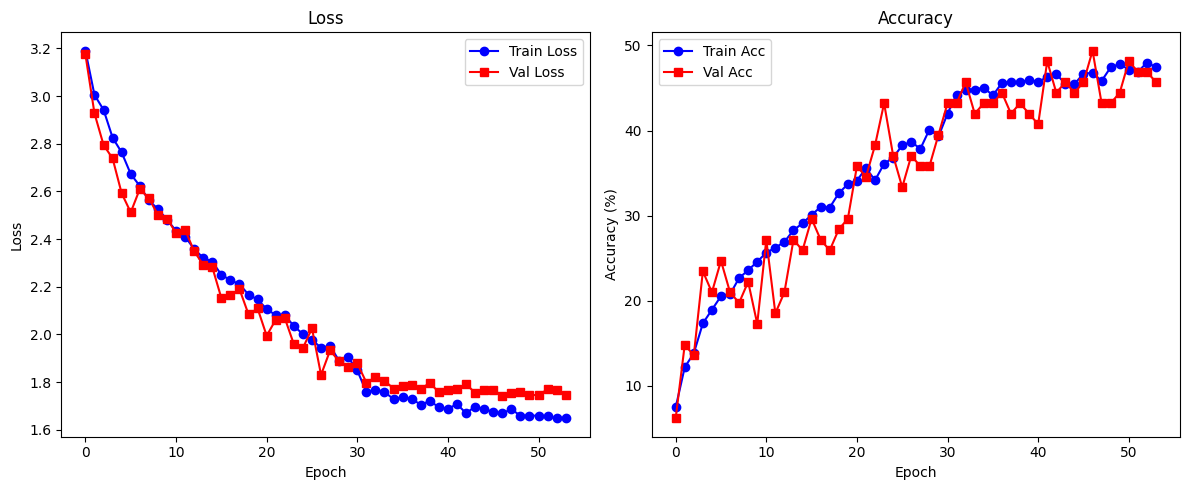

Epoch 55/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 27.87batch/s]

Train Loss: 1.6543, Train Acc: 46.60%
Val Loss: 1.7239, Val Acc: 45.68%


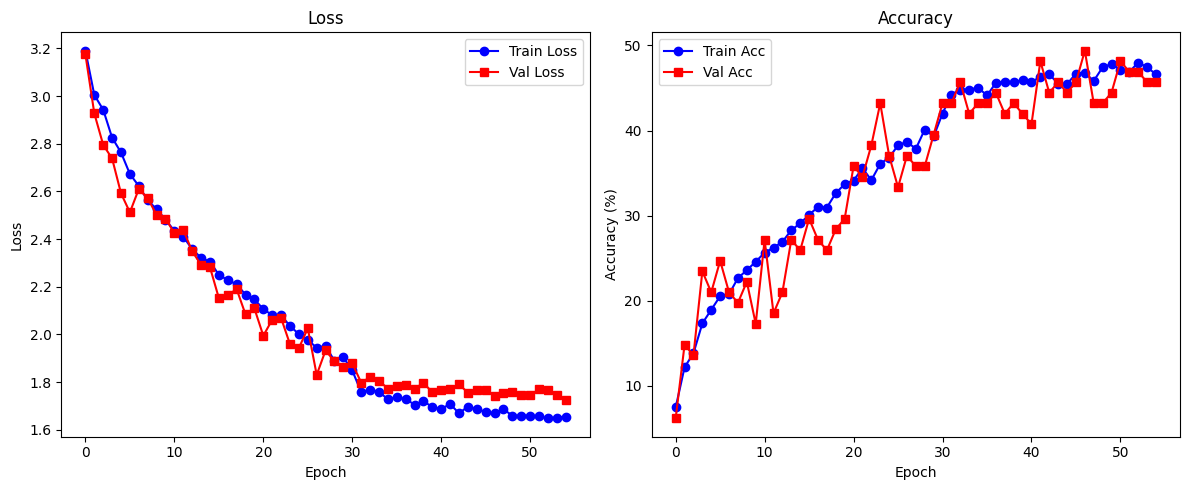

Epoch 56/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 26.21batch/s]

Train Loss: 1.6344, Train Acc: 48.06%
Val Loss: 1.7610, Val Acc: 46.91%


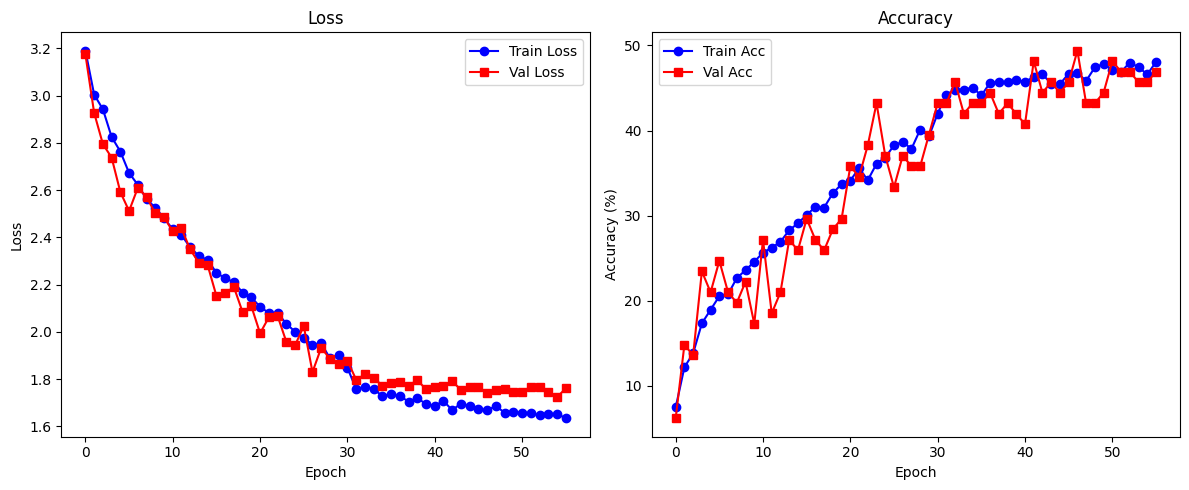

Epoch 57/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 29.37batch/s]

Train Loss: 1.6592, Train Acc: 46.20%
Val Loss: 1.7446, Val Acc: 44.44%


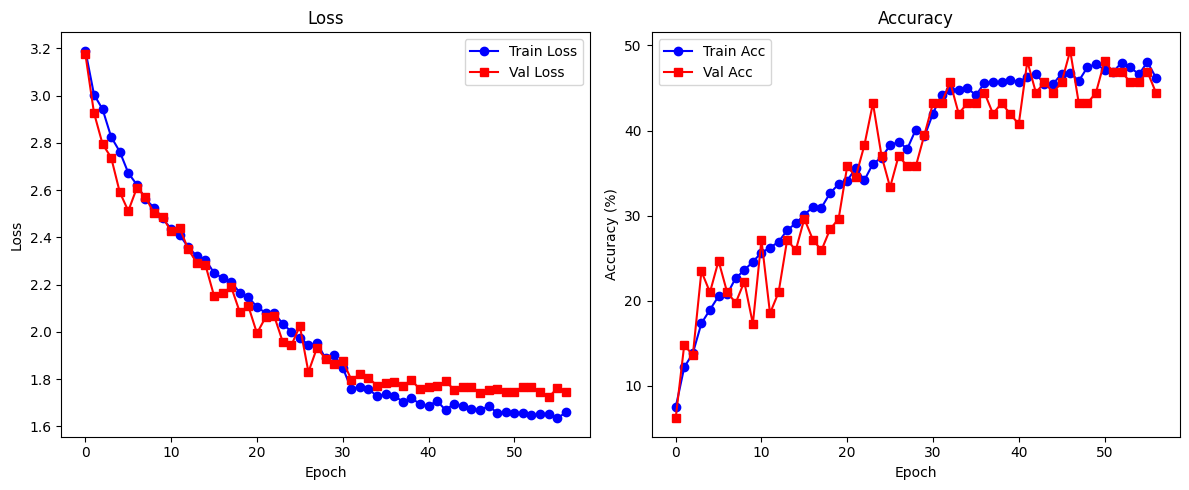

Epoch 58/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 28.75batch/s]

Train Loss: 1.6313, Train Acc: 48.01%
Val Loss: 1.7410, Val Acc: 46.91%


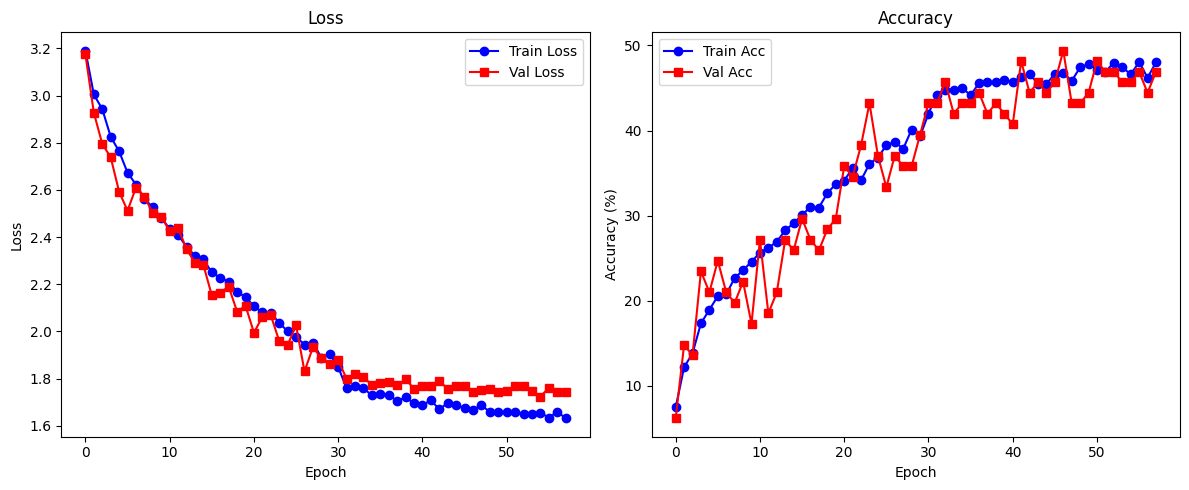

Epoch 59/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 27.98batch/s]

Train Loss: 1.6259, Train Acc: 47.92%
Val Loss: 1.7298, Val Acc: 46.91%


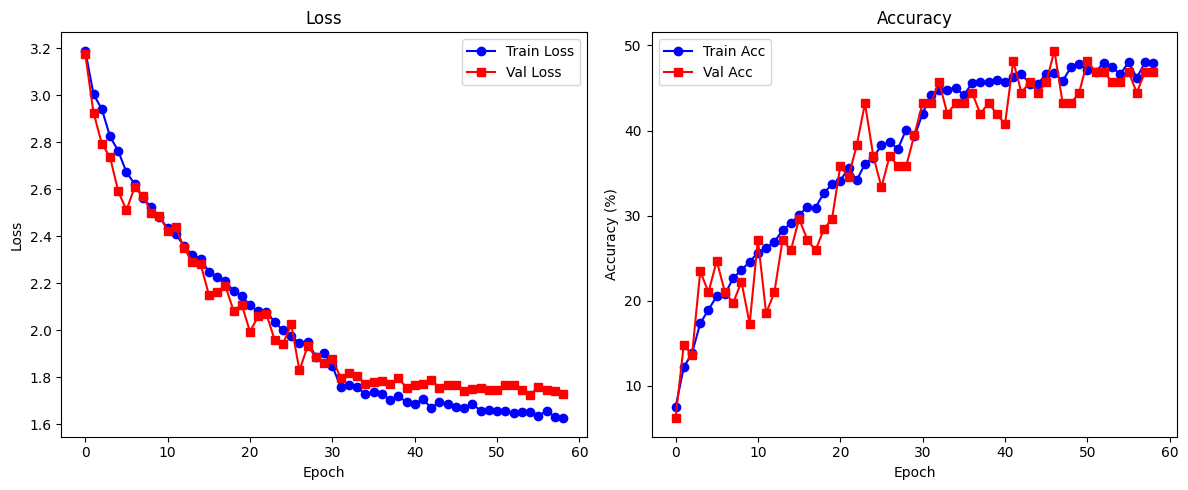

Epoch 60/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 29.11batch/s]

Train Loss: 1.6506, Train Acc: 47.50%
Val Loss: 1.7504, Val Acc: 44.44%


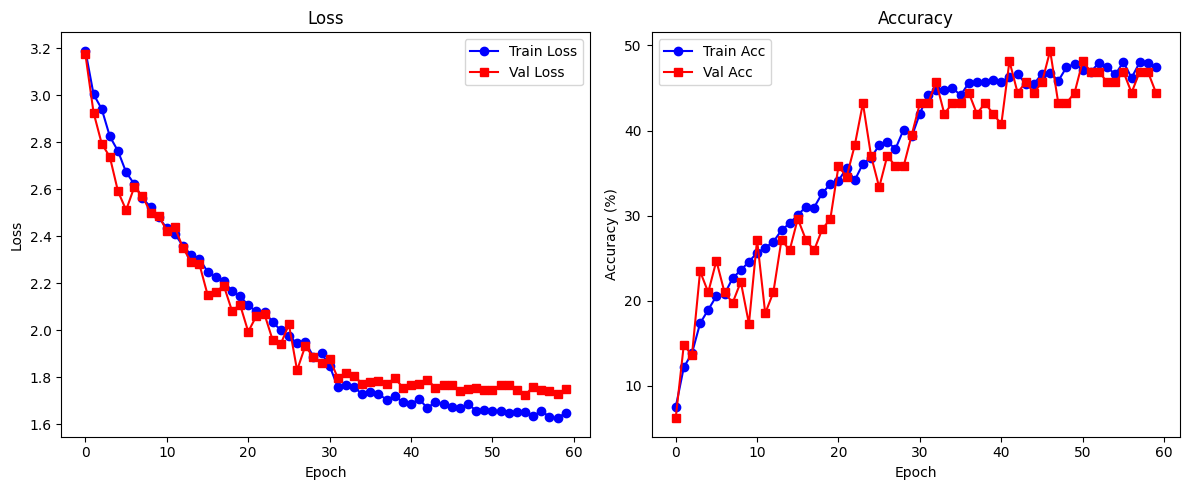

Epoch 61/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 27.73batch/s]

Train Loss: 1.6398, Train Acc: 47.55%
Val Loss: 1.7642, Val Acc: 45.68%


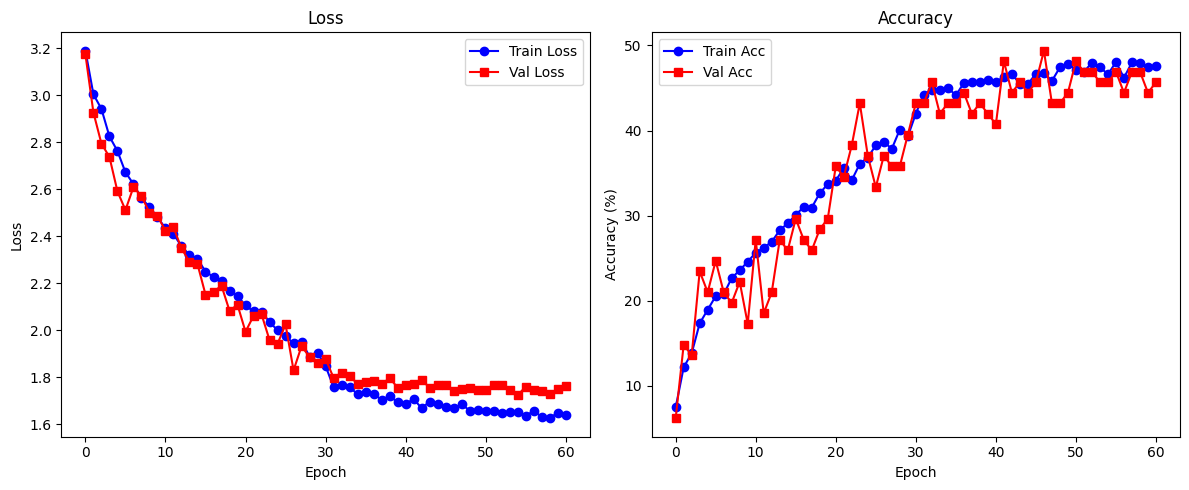

Epoch 62/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 27.23batch/s]

Train Loss: 1.6376, Train Acc: 48.17%
Val Loss: 1.7356, Val Acc: 45.68%


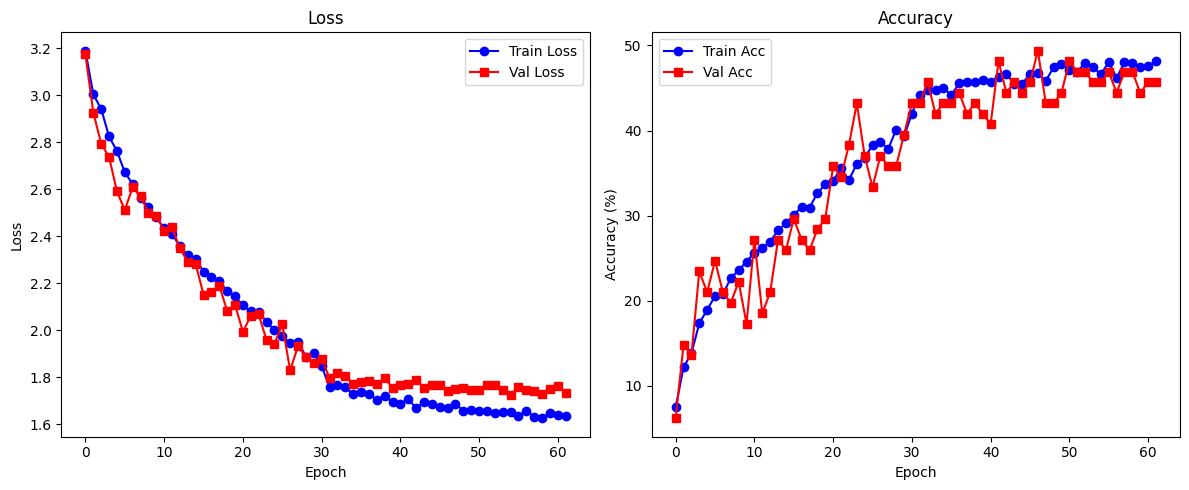

Epoch 63/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 27.49batch/s]

Train Loss: 1.6584, Train Acc: 47.52%
Val Loss: 1.7589, Val Acc: 45.68%


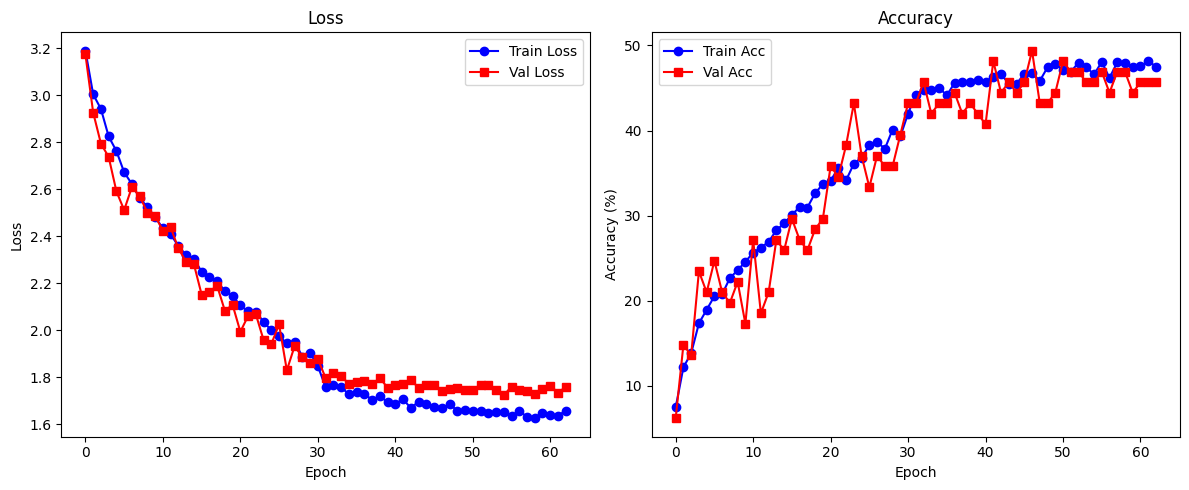

Epoch 64/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 27.46batch/s]

Train Loss: 1.6505, Train Acc: 47.66%
Val Loss: 1.7527, Val Acc: 44.44%


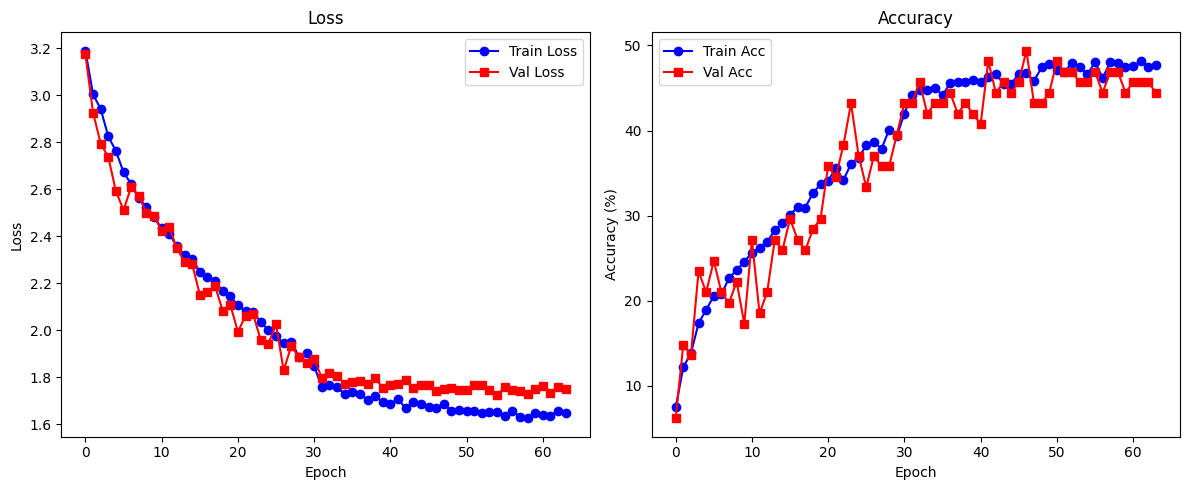

Epoch 65/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 27.88batch/s]

Train Loss: 1.6659, Train Acc: 46.97%
Val Loss: 1.7594, Val Acc: 41.98%


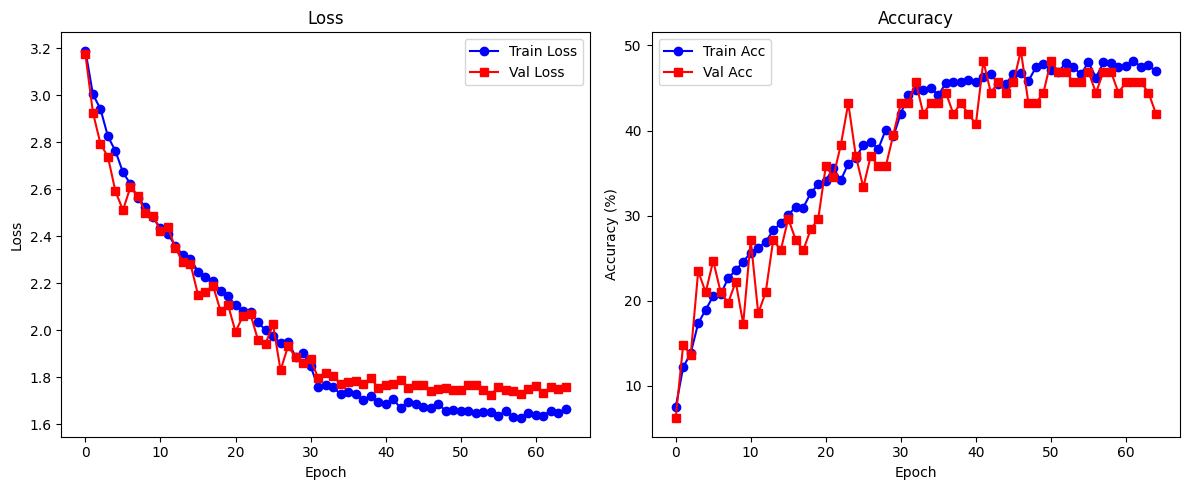

Epoch 66/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 26.94batch/s]

Train Loss: 1.6500, Train Acc: 48.06%
Val Loss: 1.7542, Val Acc: 46.91%


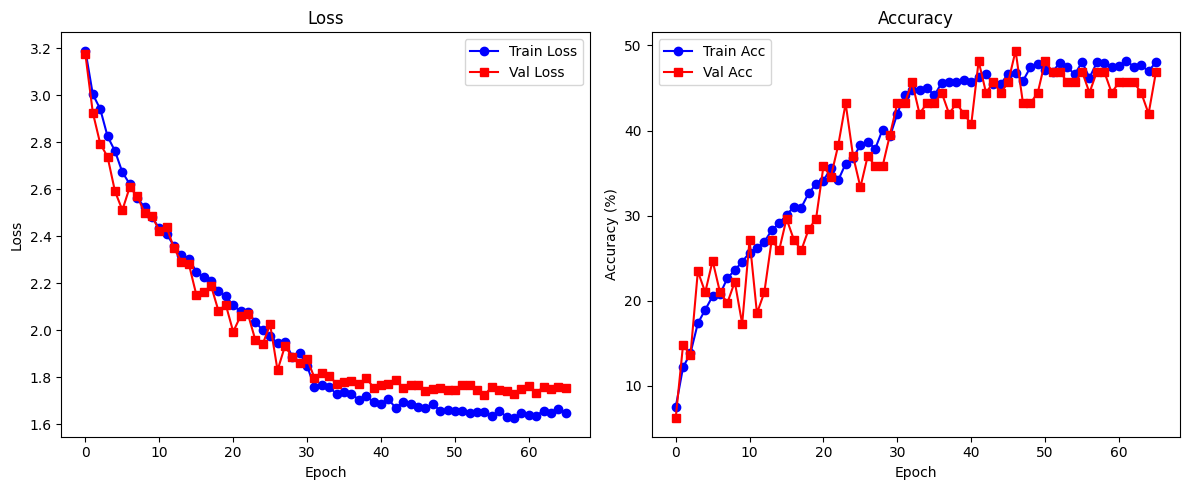

Epoch 67/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 28.23batch/s]

Train Loss: 1.6333, Train Acc: 47.25%
Val Loss: 1.7585, Val Acc: 45.68%


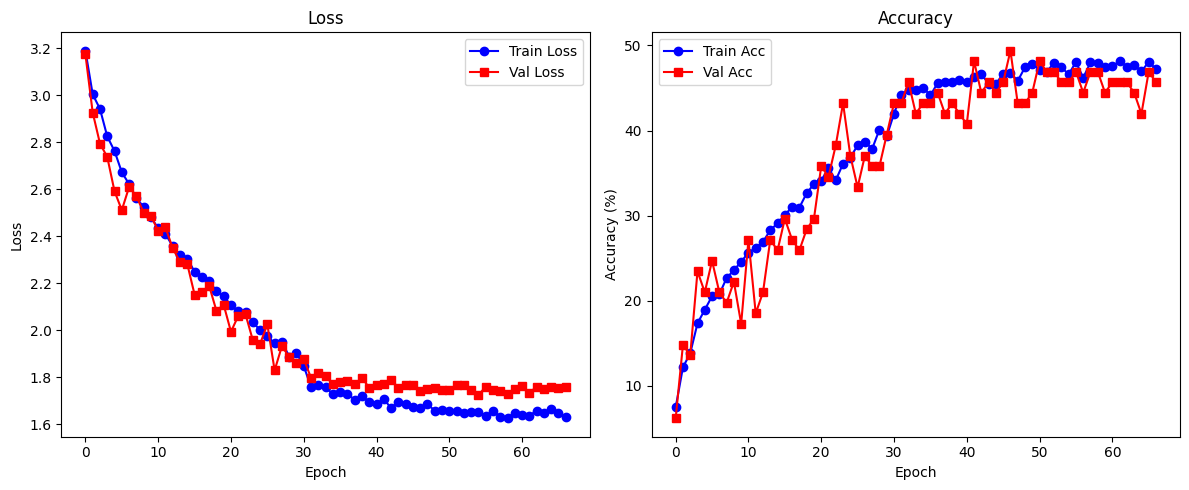

Epoch 68/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 27.98batch/s]

Train Loss: 1.6457, Train Acc: 48.06%
Val Loss: 1.7422, Val Acc: 44.44%


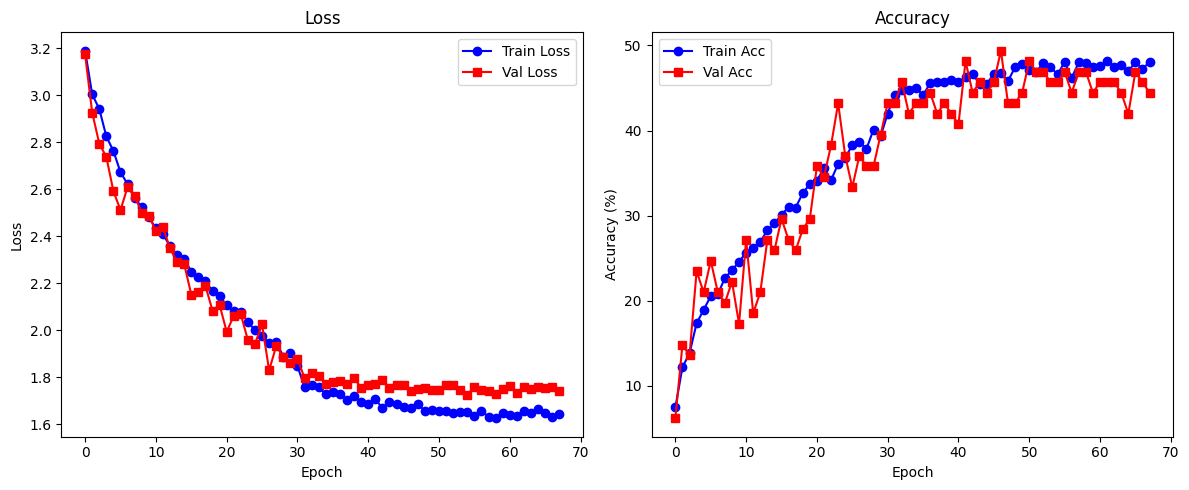

Epoch 69/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 27.79batch/s]

Train Loss: 1.6204, Train Acc: 48.17%
Val Loss: 1.7423, Val Acc: 48.15%


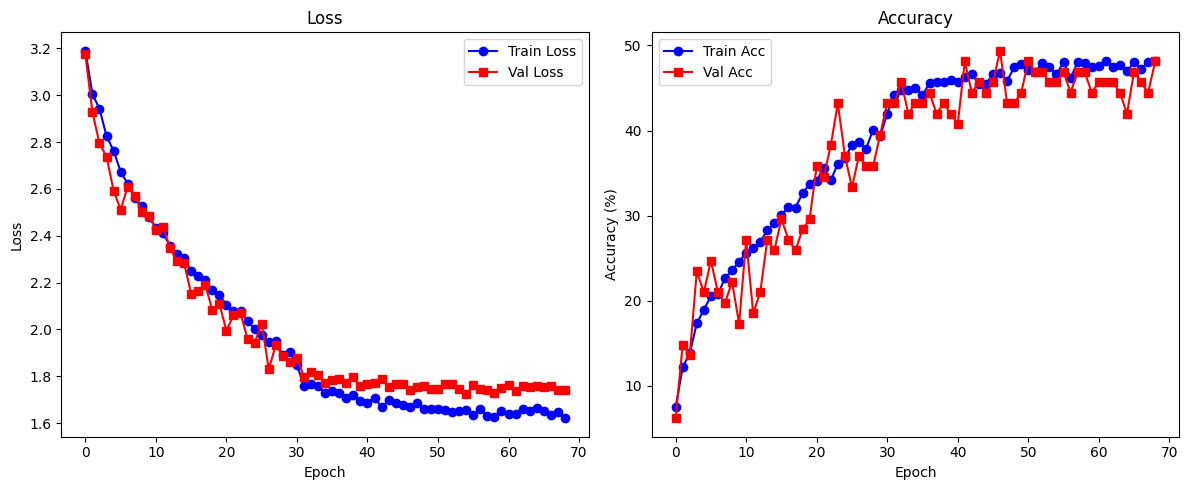

Epoch 70/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 26.44batch/s]

Train Loss: 1.6608, Train Acc: 47.71%
Val Loss: 1.7348, Val Acc: 45.68%


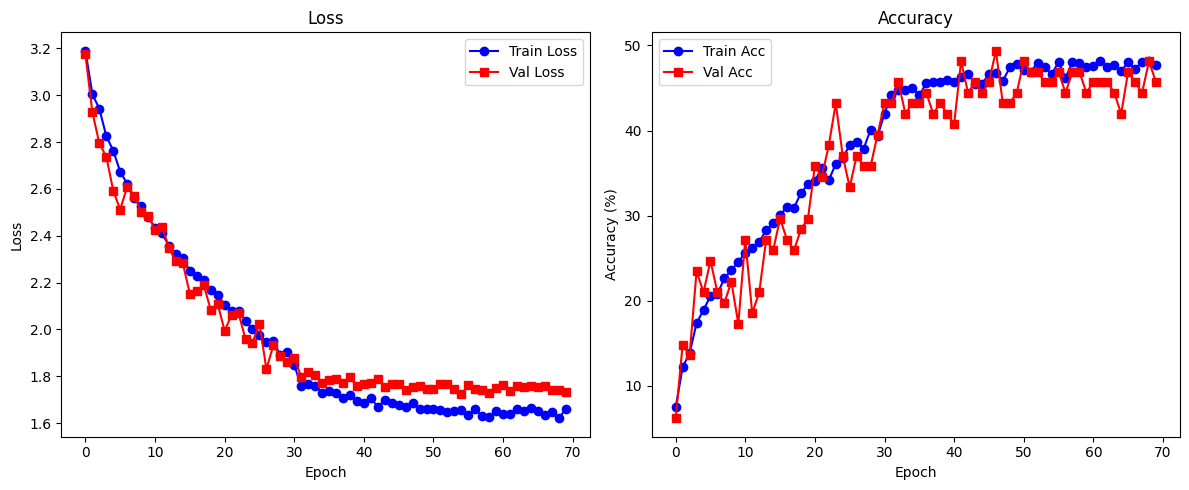

Epoch 71/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 28.94batch/s]

Train Loss: 1.6450, Train Acc: 46.85%
Val Loss: 1.7585, Val Acc: 46.91%


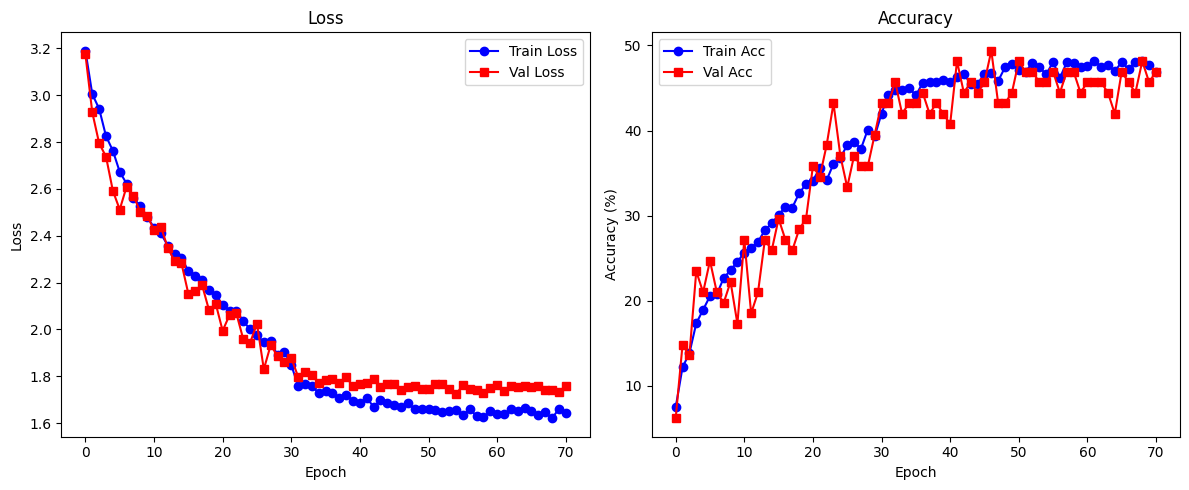

Epoch 72/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 28.64batch/s]

Train Loss: 1.6669, Train Acc: 46.71%
Val Loss: 1.7292, Val Acc: 43.21%


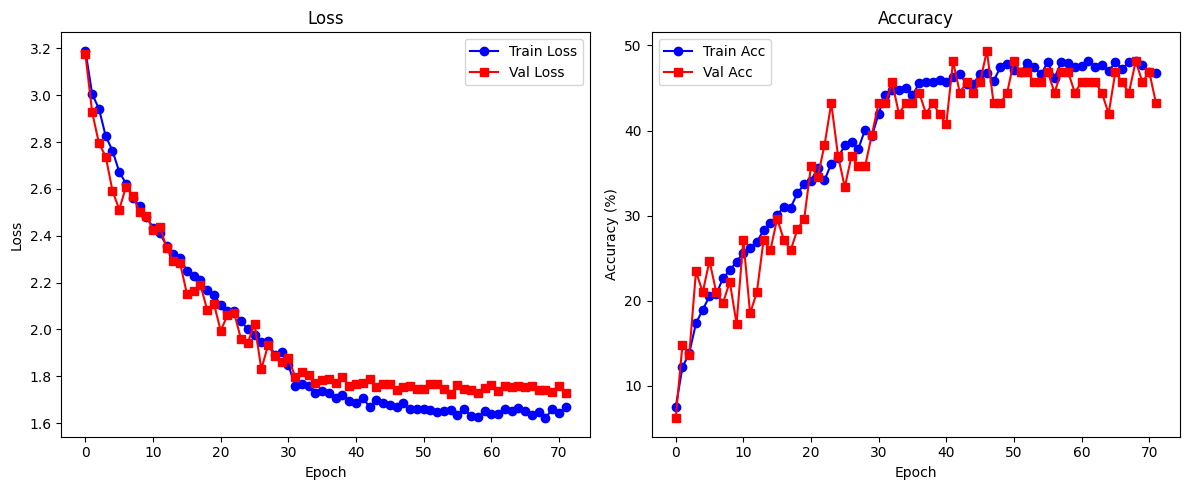

Epoch 73/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 27.72batch/s]

Train Loss: 1.6464, Train Acc: 47.66%
Val Loss: 1.7248, Val Acc: 48.15%


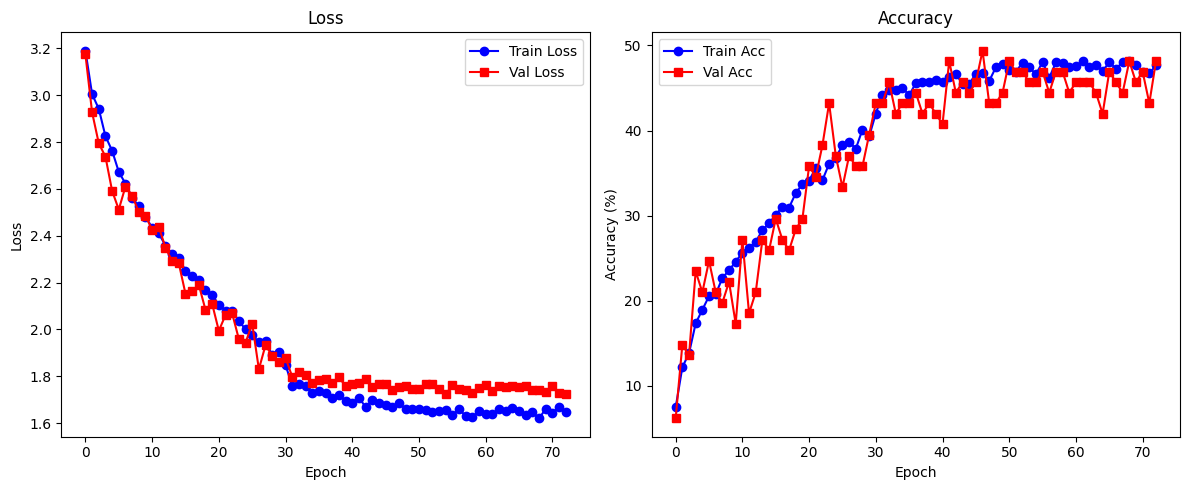

Epoch 74/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 28.84batch/s]

Train Loss: 1.6374, Train Acc: 48.56%
Val Loss: 1.7688, Val Acc: 43.21%


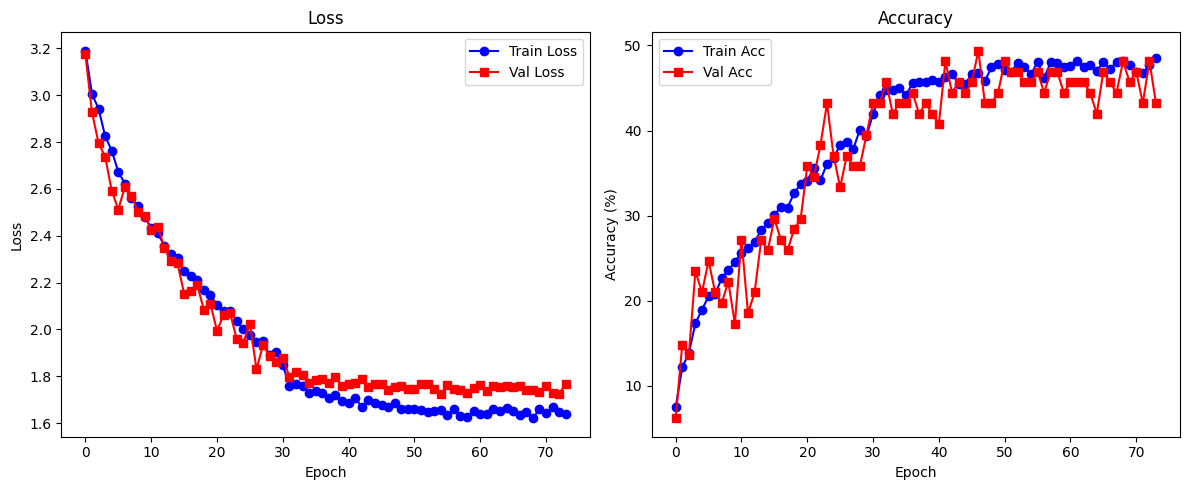

Epoch 75/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 26.86batch/s]

Train Loss: 1.6583, Train Acc: 46.90%
Val Loss: 1.7460, Val Acc: 45.68%


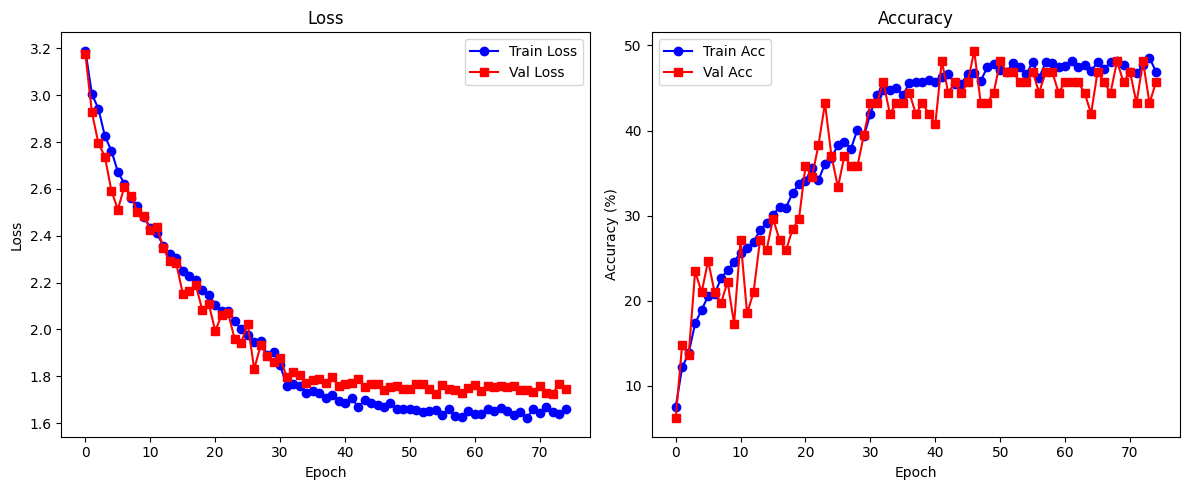

Epoch 76/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 26.73batch/s]

Train Loss: 1.6676, Train Acc: 47.20%
Val Loss: 1.7757, Val Acc: 44.44%


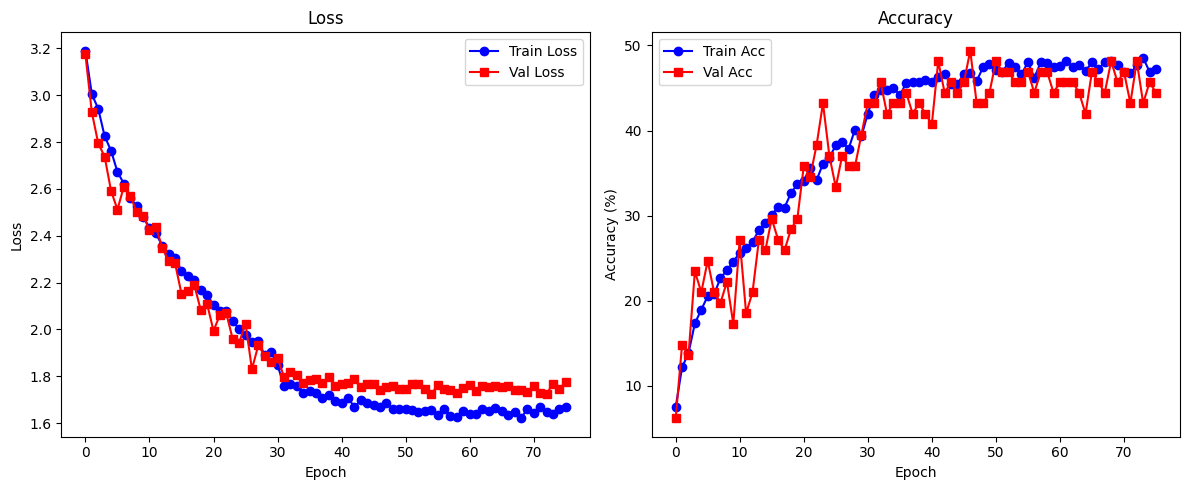

Epoch 77/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 28.85batch/s]

Train Loss: 1.6430, Train Acc: 47.85%
Val Loss: 1.7520, Val Acc: 46.91%


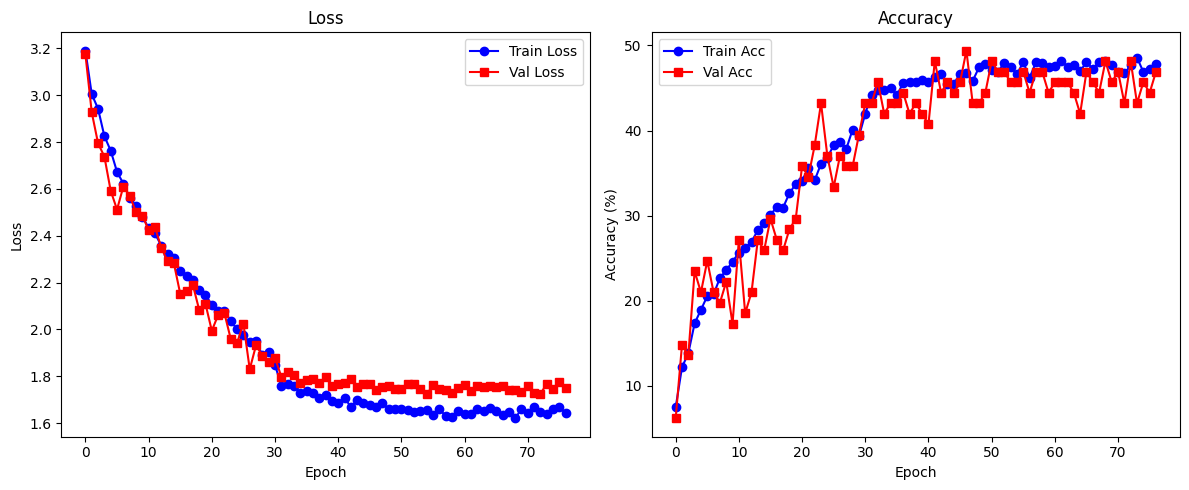

Epoch 78/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 26.93batch/s]

Train Loss: 1.6419, Train Acc: 47.48%
Val Loss: 1.7572, Val Acc: 45.68%


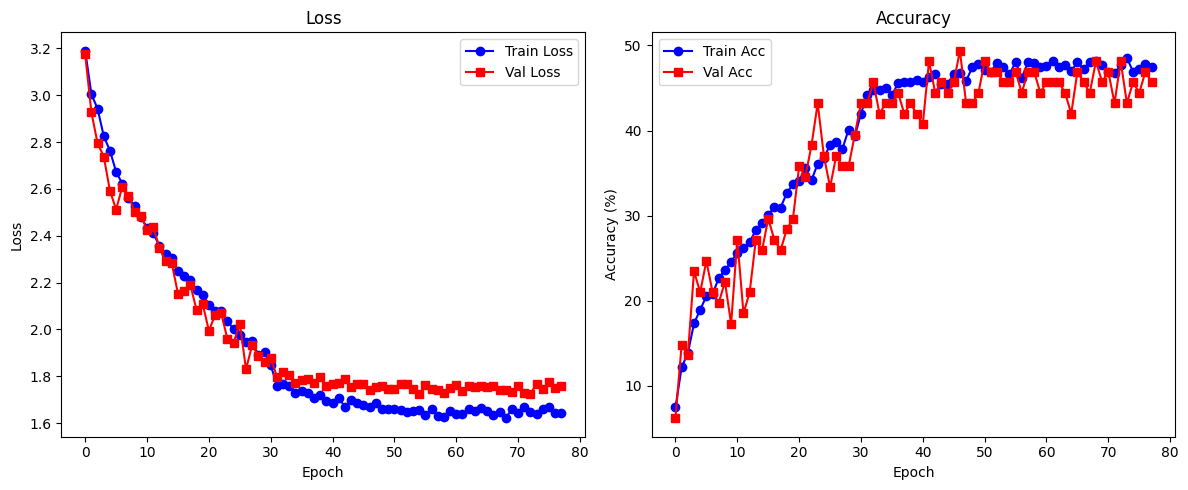

Epoch 79/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 26.13batch/s]


Train Loss: 1.6343, Train Acc: 48.01%
Val Loss: 1.7484, Val Acc: 49.38%


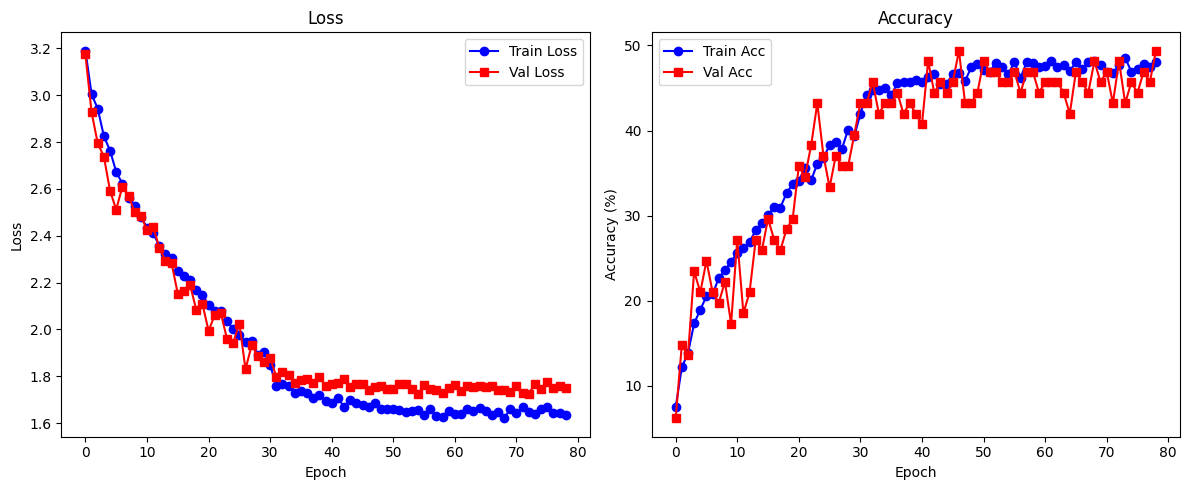

Epoch 80/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 25.28batch/s]

Train Loss: 1.6671, Train Acc: 47.50%
Val Loss: 1.7713, Val Acc: 44.44%


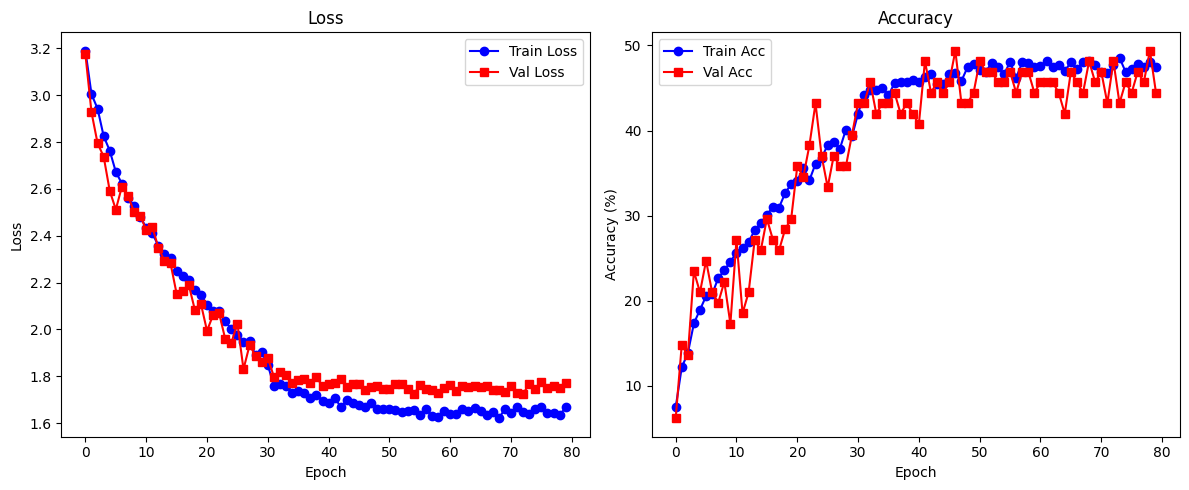

Epoch 81/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 28.48batch/s]

Train Loss: 1.6372, Train Acc: 47.52%
Val Loss: 1.7777, Val Acc: 44.44%


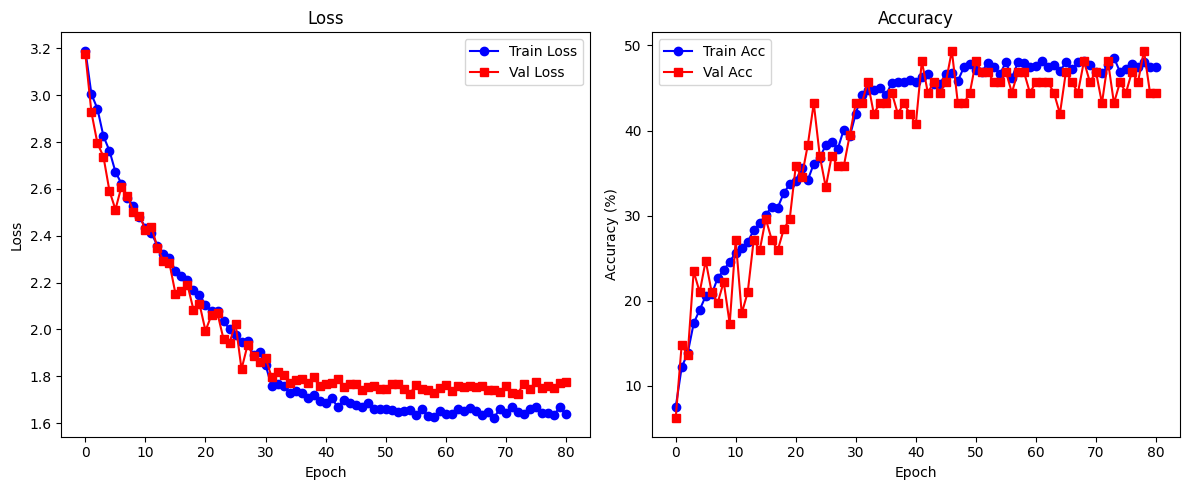

Epoch 82/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 26.86batch/s]

Train Loss: 1.6355, Train Acc: 48.08%
Val Loss: 1.7473, Val Acc: 44.44%


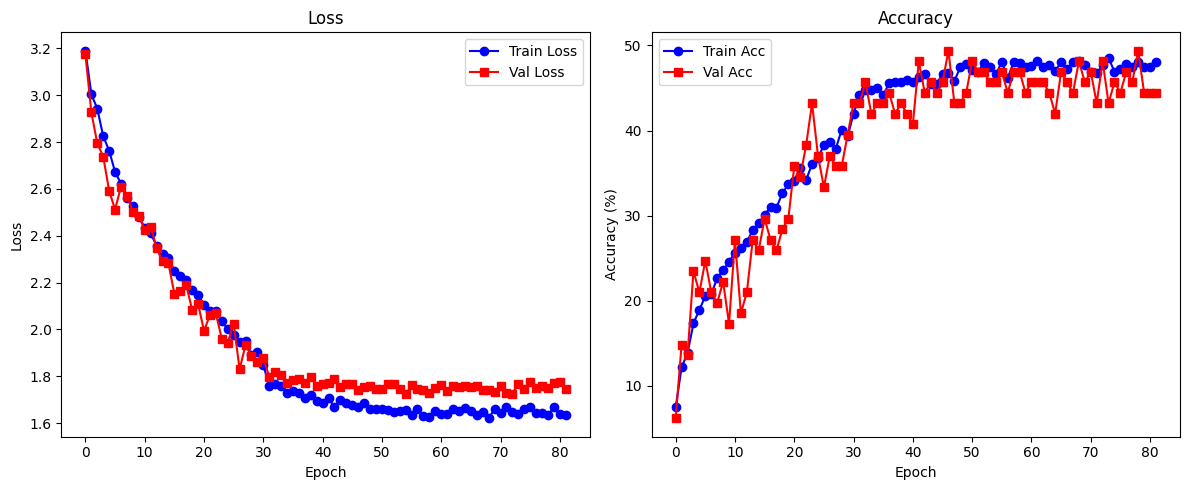

Epoch 83/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 26.93batch/s]

Train Loss: 1.6433, Train Acc: 47.82%
Val Loss: 1.7337, Val Acc: 45.68%


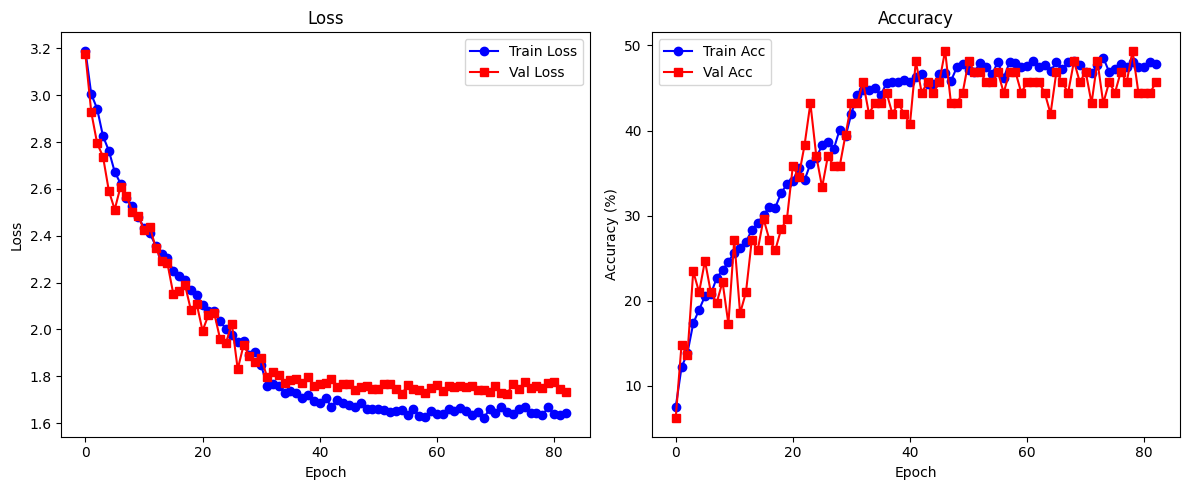

Epoch 84/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 28.40batch/s]

Train Loss: 1.6527, Train Acc: 47.08%
Val Loss: 1.7363, Val Acc: 46.91%


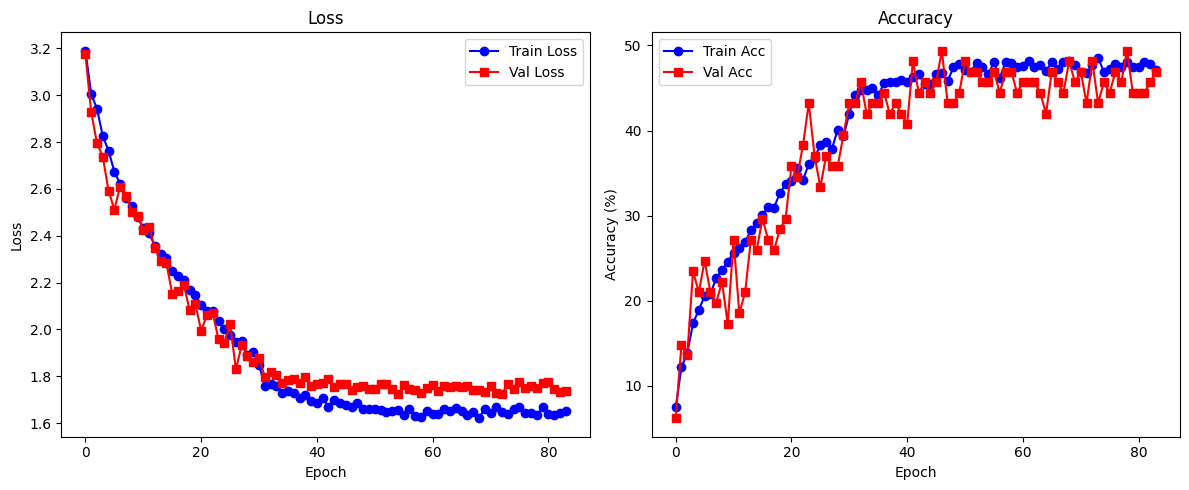

Epoch 85/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 29.11batch/s]

Train Loss: 1.6564, Train Acc: 47.15%
Val Loss: 1.7480, Val Acc: 46.91%


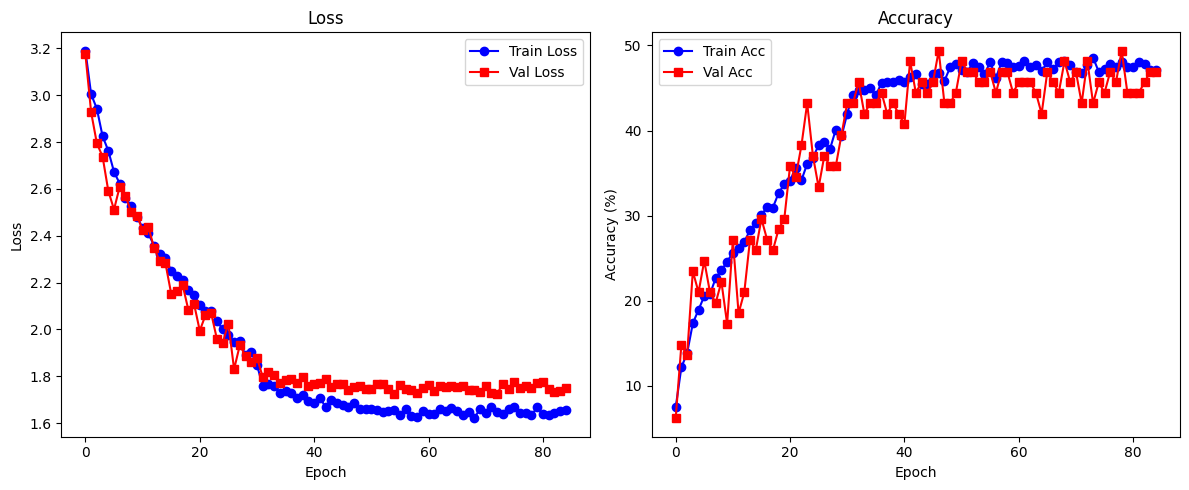

Epoch 86/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 27.32batch/s]

Train Loss: 1.6510, Train Acc: 48.40%
Val Loss: 1.7535, Val Acc: 45.68%


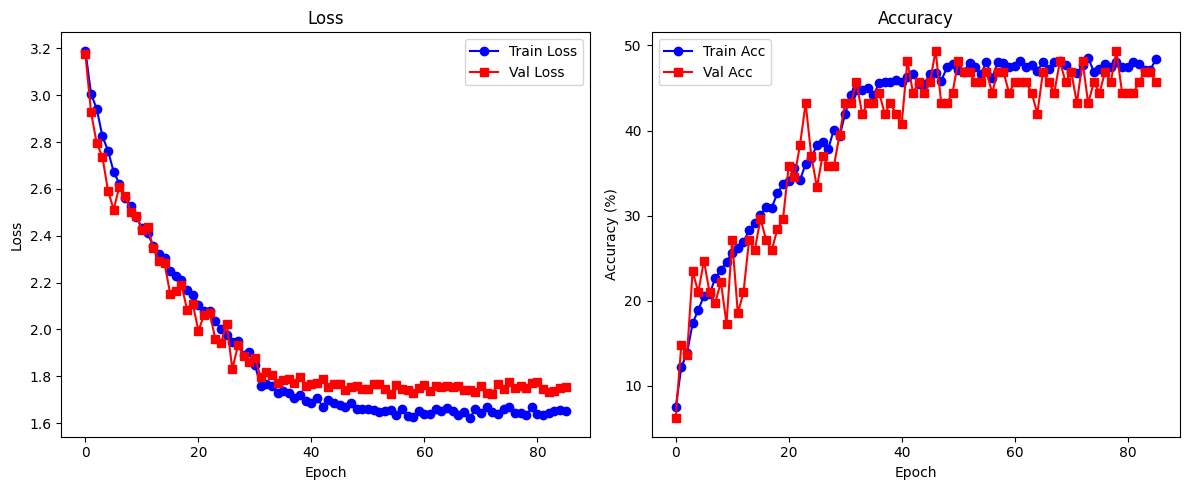

Epoch 87/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 30.28batch/s]


Train Loss: 1.6560, Train Acc: 47.73%
Val Loss: 1.7840, Val Acc: 41.98%


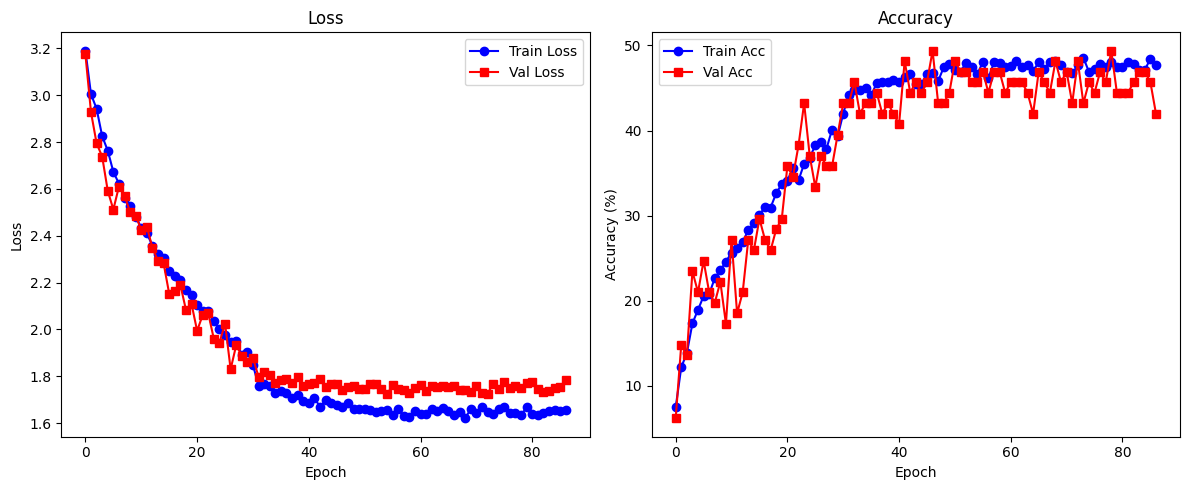

Epoch 88/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 28.76batch/s]

Train Loss: 1.6527, Train Acc: 46.60%
Val Loss: 1.7433, Val Acc: 45.68%


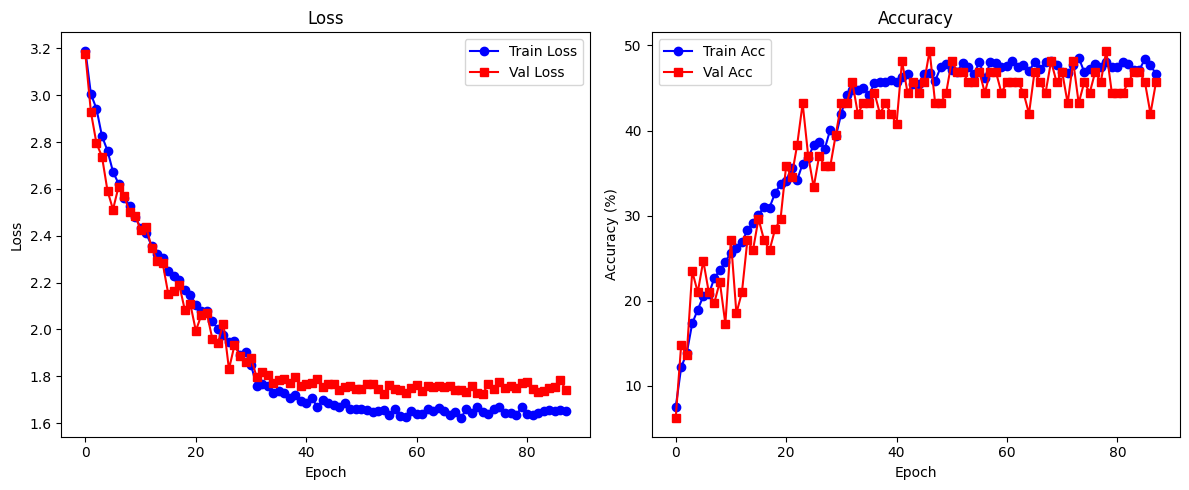

Epoch 89/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 27.90batch/s]

Train Loss: 1.6323, Train Acc: 47.59%
Val Loss: 1.7351, Val Acc: 44.44%


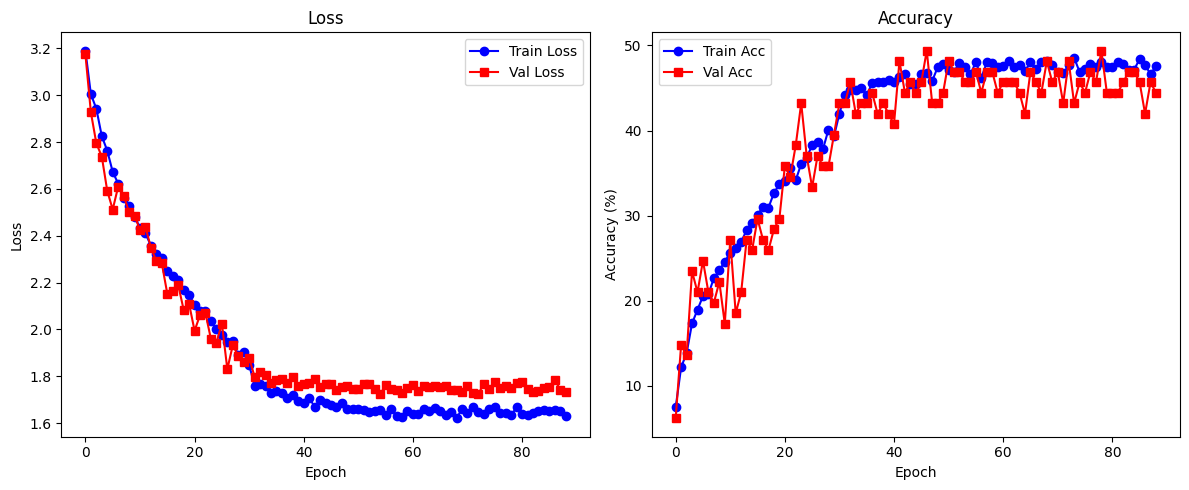

Epoch 90/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 27.16batch/s]

Train Loss: 1.6491, Train Acc: 47.04%
Val Loss: 1.7413, Val Acc: 44.44%


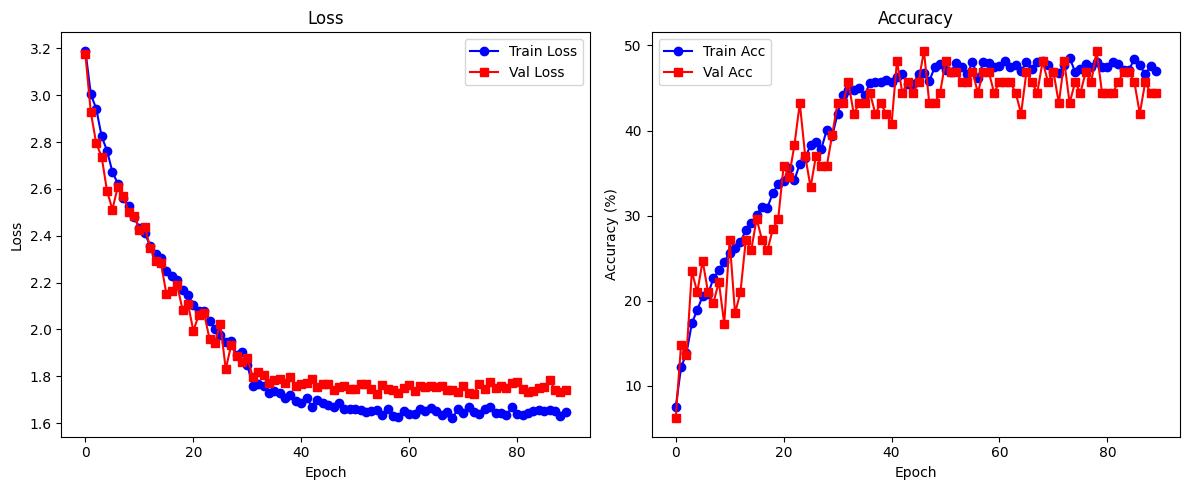

Epoch 91/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 29.29batch/s]

Train Loss: 1.6578, Train Acc: 46.44%
Val Loss: 1.7471, Val Acc: 44.44%


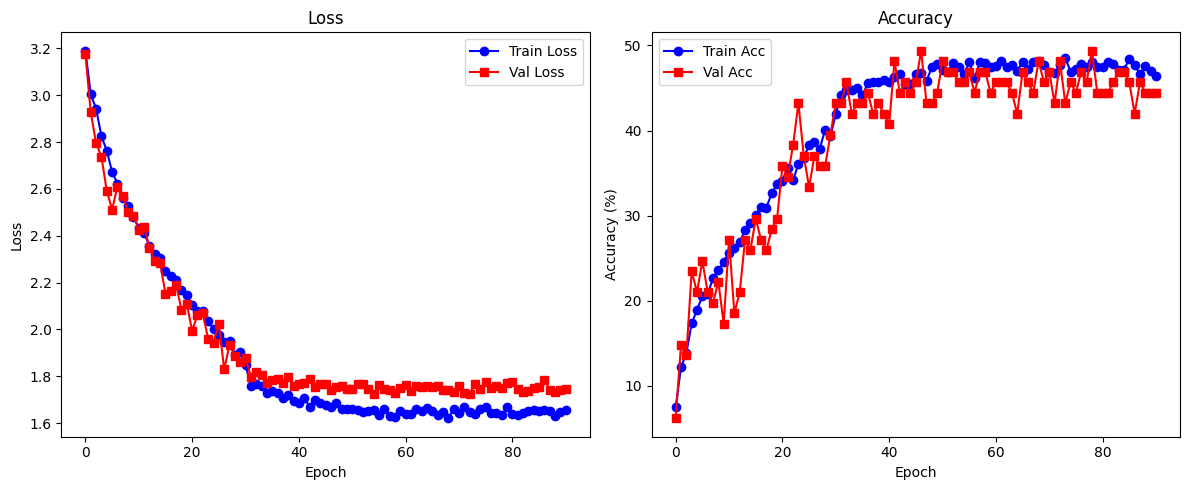

Epoch 92/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 29.45batch/s]

Train Loss: 1.6145, Train Acc: 48.63%
Val Loss: 1.7382, Val Acc: 46.91%


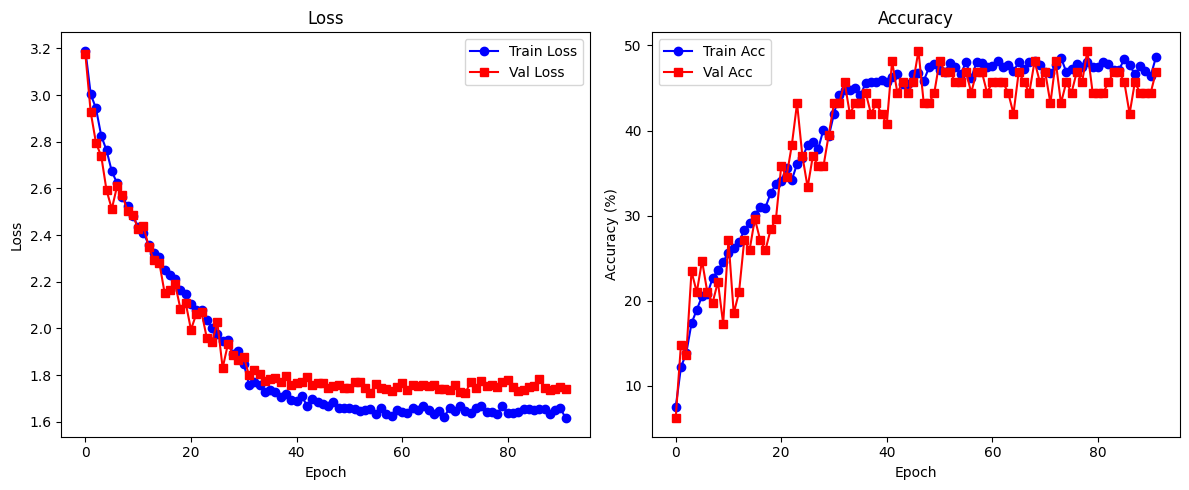

Epoch 93/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 29.70batch/s]

Train Loss: 1.6564, Train Acc: 47.20%
Val Loss: 1.7617, Val Acc: 45.68%


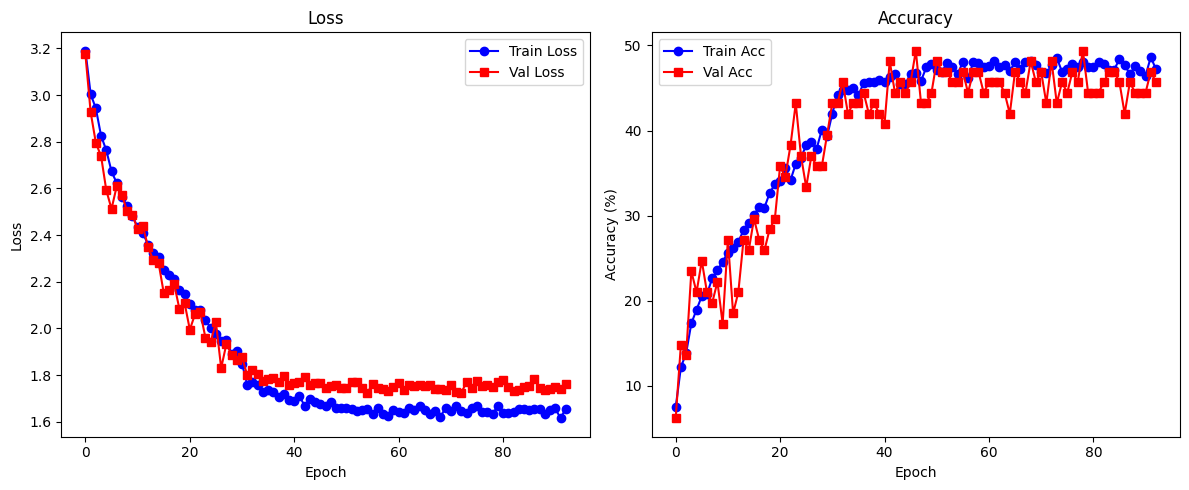

Epoch 94/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 28.06batch/s]

Train Loss: 1.6338, Train Acc: 47.73%
Val Loss: 1.7393, Val Acc: 46.91%


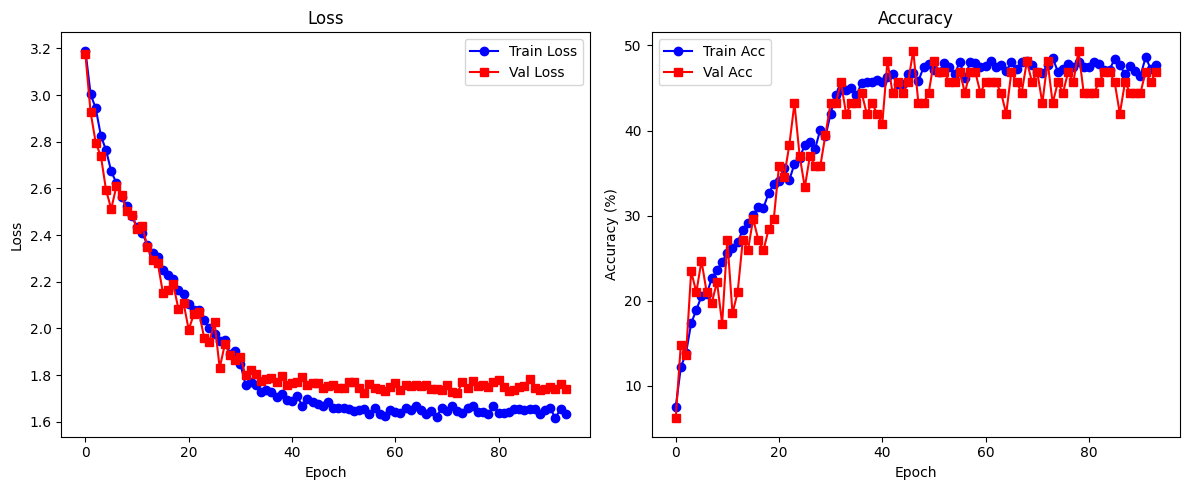

Epoch 95/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 29.43batch/s]

Train Loss: 1.6498, Train Acc: 47.04%
Val Loss: 1.7494, Val Acc: 44.44%


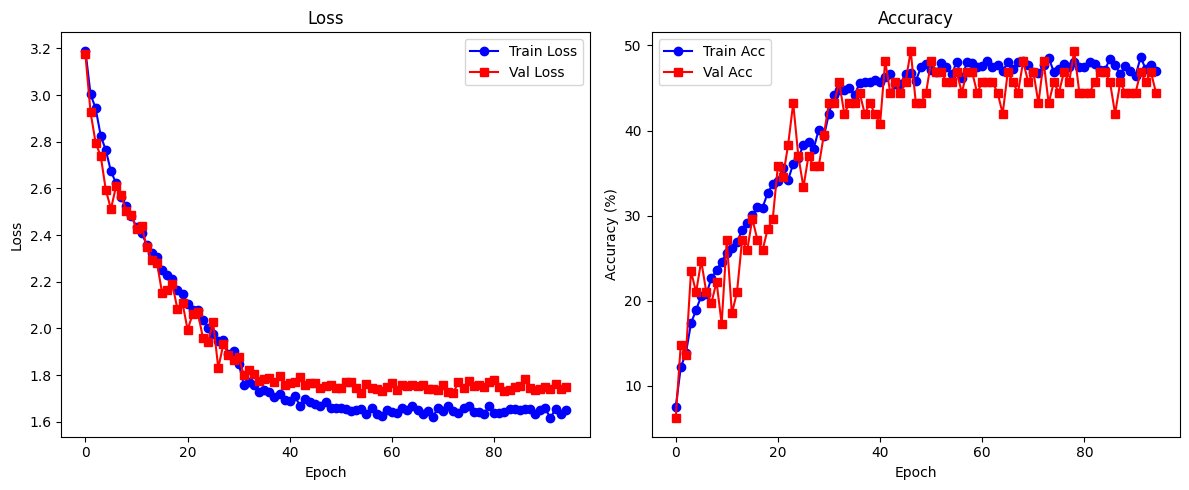

Epoch 96/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 25.95batch/s]

Train Loss: 1.6741, Train Acc: 46.44%
Val Loss: 1.7408, Val Acc: 46.91%


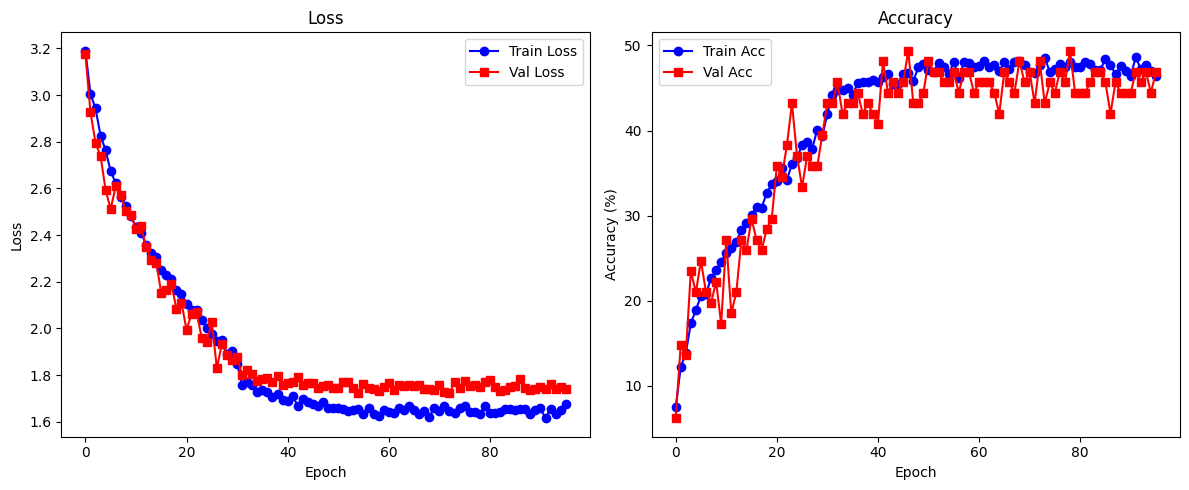

Epoch 97/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 25.83batch/s]

Train Loss: 1.6460, Train Acc: 47.52%
Val Loss: 1.7410, Val Acc: 44.44%


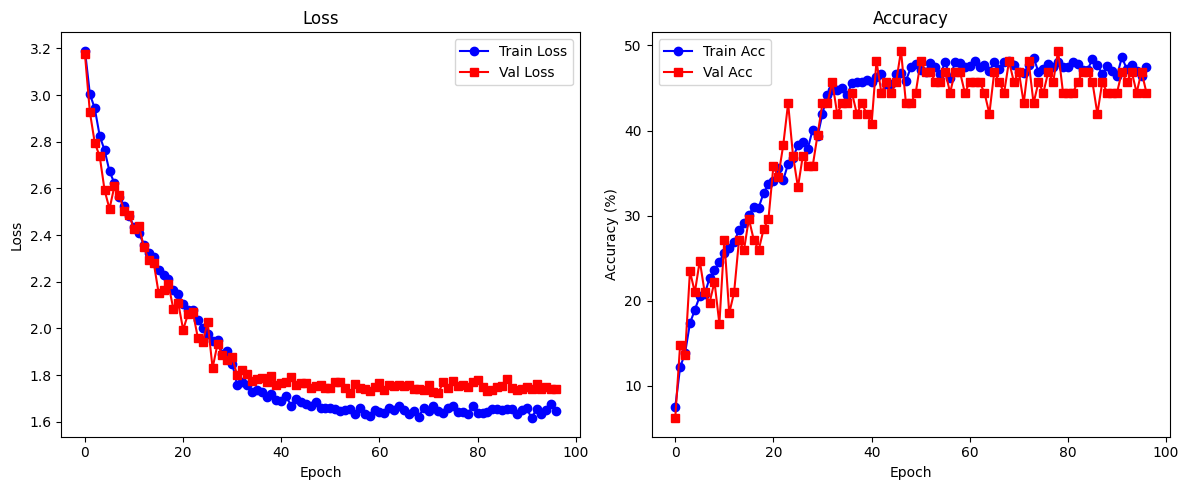

Epoch 98/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 24.79batch/s]


Train Loss: 1.6402, Train Acc: 47.43%
Val Loss: 1.7333, Val Acc: 43.21%


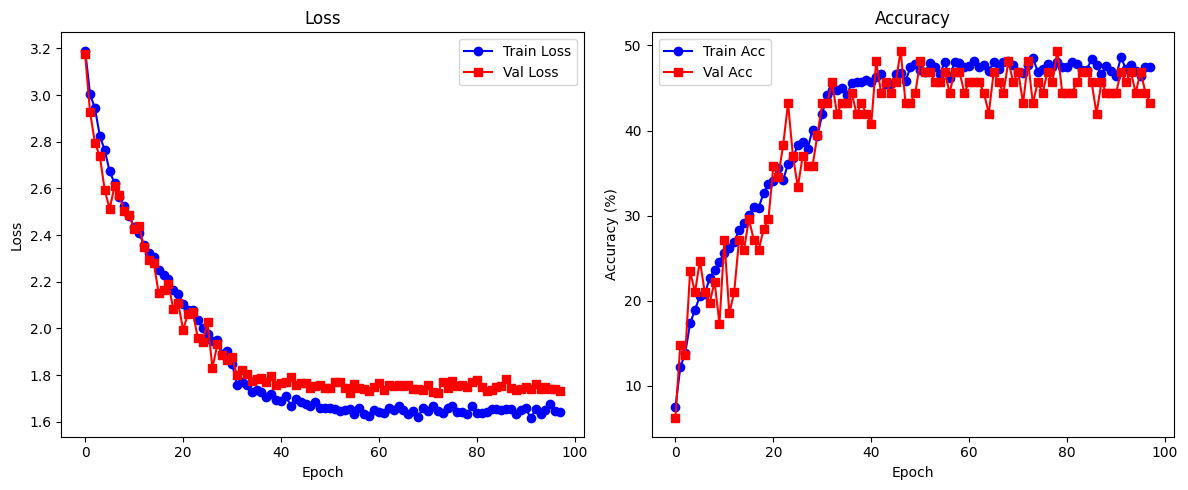

Epoch 99/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 22.53batch/s]


Train Loss: 1.6572, Train Acc: 47.62%
Val Loss: 1.7790, Val Acc: 45.68%


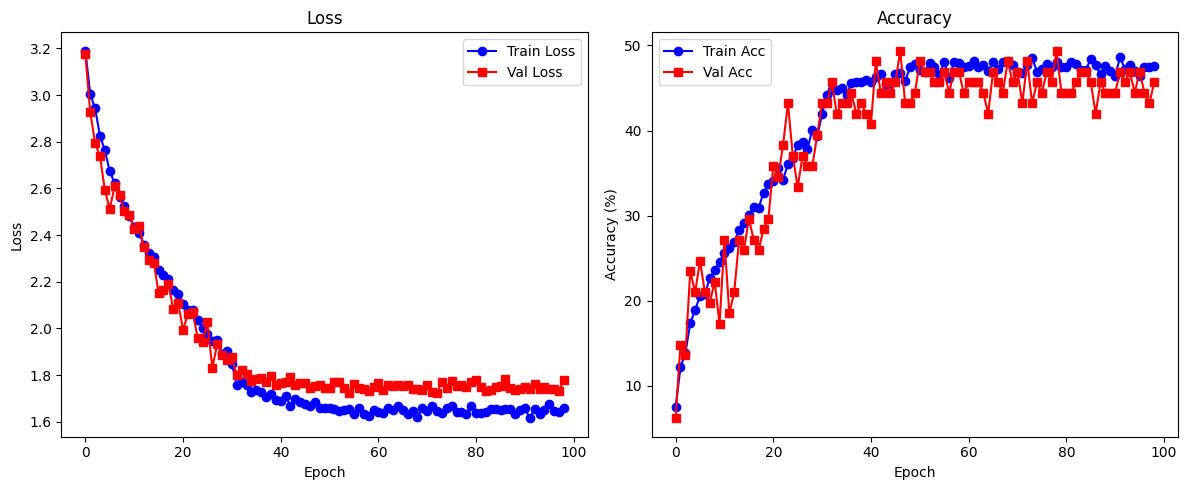

Epoch 100/100
------------------------------


Validation: 100%|██████████| 6/6 [00:00<00:00, 28.06batch/s]

Train Loss: 1.6465, Train Acc: 48.89%
Val Loss: 1.7693, Val Acc: 41.98%


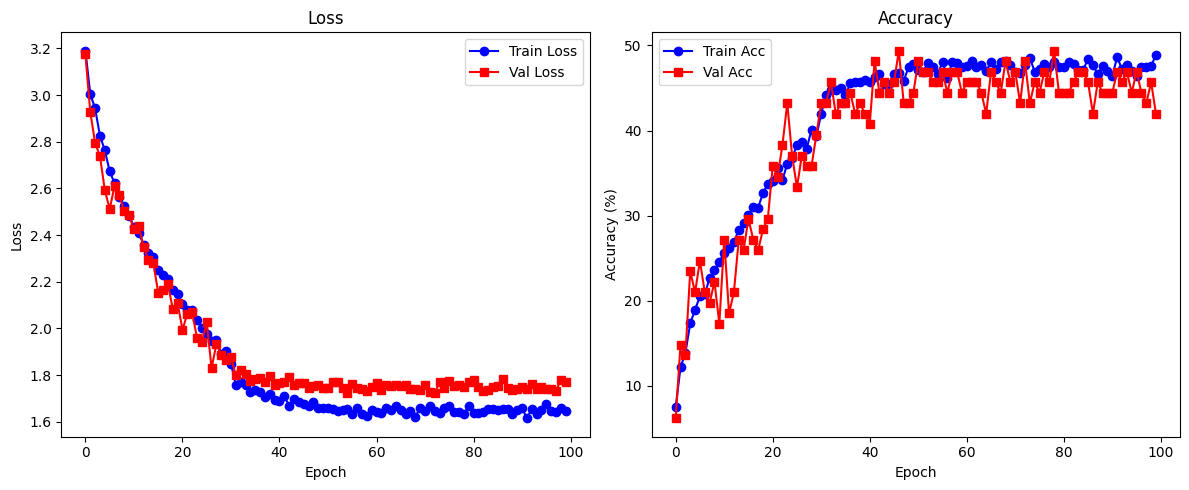

In [8]:
%matplotlib inline
history_path = 'vit_training_history.json'
# Load previous history if exists
if os.path.exists(history_path):
    with open(history_path, 'r') as f:
        history = json.load(f)
    train_losses = history.get('train_losses', [])
    val_losses = history.get('val_losses', [])
    train_accs = history.get('train_accs', [])
    val_accs = history.get('val_accs', [])
    start_epoch = len(train_losses)
    print(f'Resuming from epoch {start_epoch}')
    # Set best_val_acc to max historical value if available
    best_val_acc = max(val_accs) if val_accs else 0.0
else:
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    start_epoch = 0
    best_val_acc = 0.0
num_epochs = 100
for epoch in range(start_epoch, num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print('-' * 30)
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc='Training', unit='batch'):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    train_loss = running_loss / total
    train_acc = correct / total * 100
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validation', unit='batch'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total * 100
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    scheduler.step(val_loss)
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_vit_model.pth')
        print(f'✓ Saved best model (val_acc: {val_acc:.2f}%)')
    # Save history after each epoch
    history = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs
    }
    with open(history_path, 'w') as f:
        json.dump(history, f)
    # Plot after each epoch
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, 'b-o', label='Train Loss')
    plt.plot(val_losses, 'r-s', label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, 'b-o', label='Train Acc')
    plt.plot(val_accs, 'r-s', label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

## Test Evaluation and Confusion Matrix

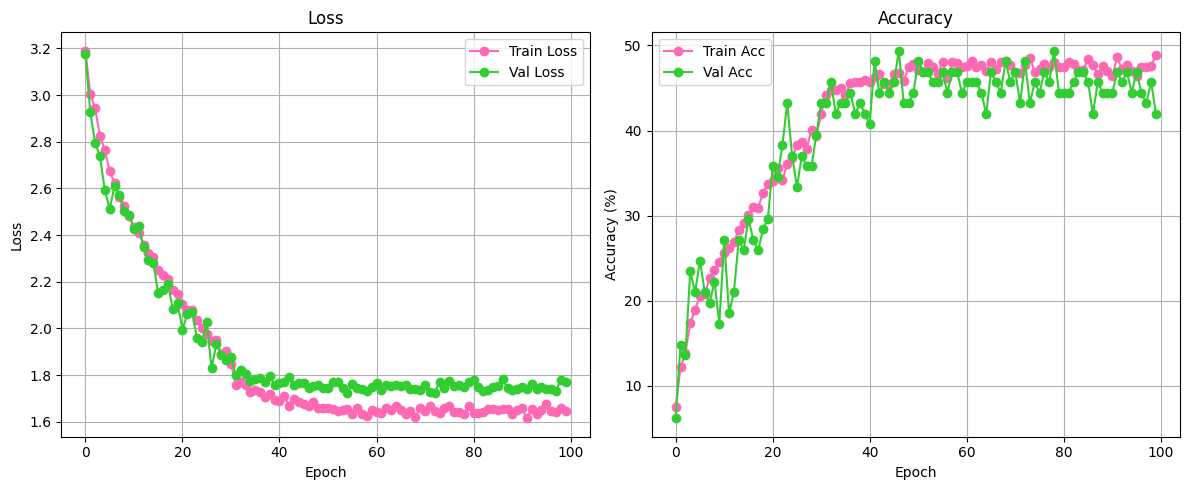

In [12]:
# Plot full training history after training with pink and green lines, round markers, and grid
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, color='hotpink', marker='o', label='Train Loss', markersize=6)
plt.plot(val_losses, color='limegreen', marker='o', label='Val Loss', markersize=6)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(train_accs, color='hotpink', marker='o', label='Train Acc', markersize=6)
plt.plot(val_accs, color='limegreen', marker='o', label='Val Acc', markersize=6)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('vit_training_history.png', dpi=150)
plt.show()

Testing: 100%|██████████| 17/17 [00:01<00:00, 14.05batch/s]


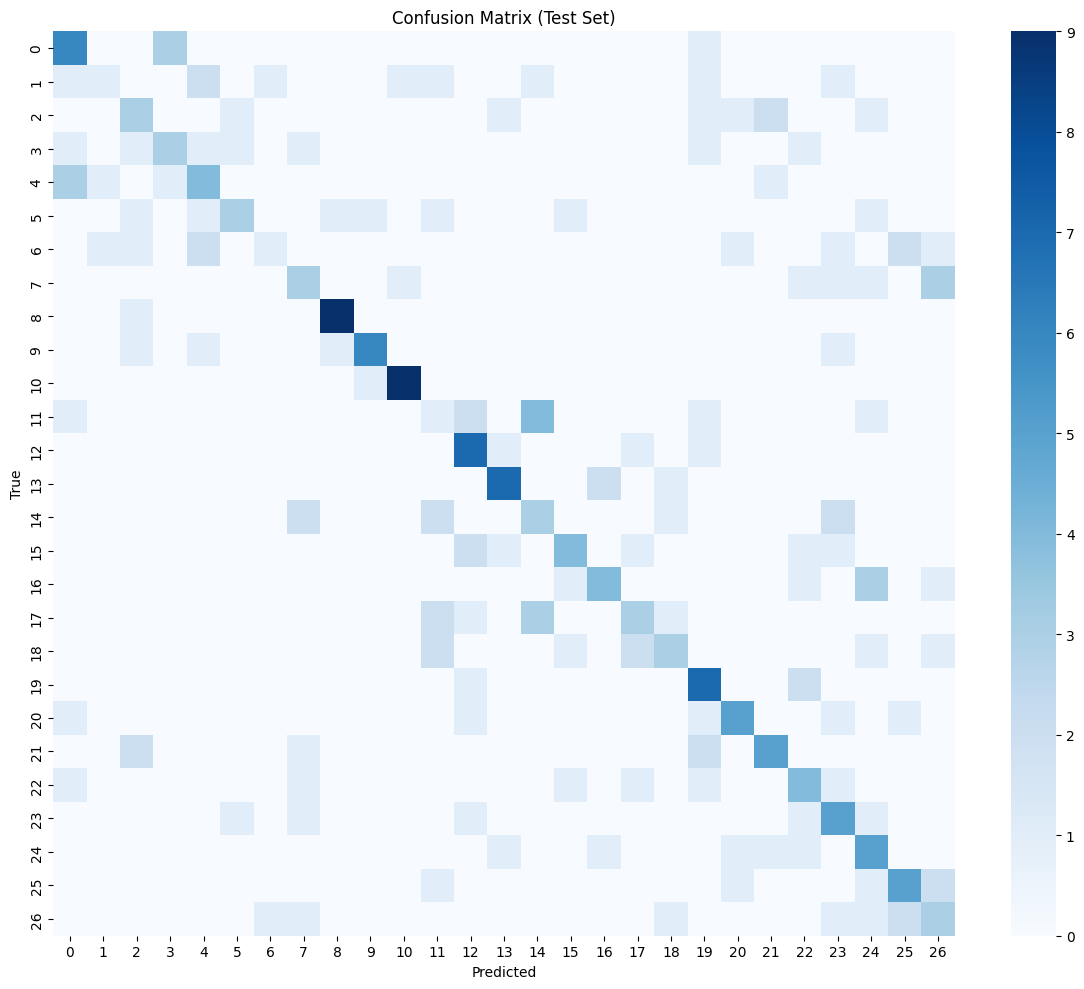

Mean class accuracy: 0.4407


In [9]:
model.load_state_dict(torch.load('best_vit_model.pth'))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing', unit='batch'):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues', cbar=True)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()
class_acc = cm.diagonal() / cm.sum(axis=1)
print(f'Mean class accuracy: {np.nanmean(class_acc):.4f}')

In [14]:
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Test images: {len(test_dataset)}")
print(f"Number of classes: {len(class_names)}")


Total parameters: 1,120,532
Training images: 4320
Validation images: 81
Test images: 270
Number of classes: 27
